<a href="https://colab.research.google.com/github/hassnainnisar/Predict_seismic_events_from_geological_features_Machine_Learning_MOD_B/blob/main/Machine_Learning_MOD_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Machine Learning-Based Prediction of Seismic Activity at Campi Flegrei Using Temporal Features**

**Project Objective**

To develop machine learning regression models capable of predicting future seismic activity at the Campi Flegrei caldera using historical seismic characteristics and temporal features.

**Problem Statement**

Campi Flegrei is an active volcanic area near Naples, Italy, where seismic activity is an important indicator of changes occurring within the volcanic system. The objective of this project is to analyze historical seismic data and develop machine learning models to predict future seismic activity. The project focuses on temporal patterns in seismic events, including event frequency, magnitude, depth, and historical activity. Time-series features such as lagged observations and rolling statistics will be engineered and used as input variables for regression models.

**Dataset:**
Campi Flegrei Caldera Seismic Data

**Source:**
Zenodo

**Data Type:**
Temporal / Time-Series Data

**ML Task:**
Regression

**Target:**
Future Seismic Event Count

In [166]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

**Load Dataset**

In [167]:
import pandas as pd

file_path = "https://raw.githubusercontent.com/hassnainnisar/Predict_seismic_events_from_geological_features_Machine_Learning_MOD_B/main/Campi__Seismic_dataset.xlsx"

# Check available sheets
excel_file = pd.ExcelFile(file_path)

excel_file.sheet_names

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [168]:

df_2000_2024 = pd.read_excel(
    file_path,
    sheet_name='2000-2024'
)

In [169]:
print("2000–2024 dataset shape:", df_2000_2024.shape)
print("Rows:", df_2000_2024.shape[0])
print("Columns:", df_2000_2024.shape[1])

2000–2024 dataset shape: (8703, 6)
Rows: 8703
Columns: 6


In [170]:
print("\n2000–2024:")
display(df_2000_2024.head(10))

print("\n2000–2024:")
display(df_2000_2024.tail(10))


2000–2024:


,Time\n (MM/DD/YYYY),Seismic Event Count,Unnamed: 2,Time\n(MM/DD/YYYY),Magnitude (Mw),Depth (km)
0,2000-01-15,0.0,NaN,2005-03-15,0.36,1.39
1,2000-02-15,0.0,NaN,2005-03-15,-0.49,1.00
2,2000-03-15,0.0,NaN,2005-05-15,0.80,1.14
3,2000-04-15,0.0,NaN,2005-06-15,0.40,2.00
4,2000-05-15,0.0,NaN,2005-09-15,0.60,2.00
5,2000-06-15,0.0,NaN,2005-10-15,0.70,2.00
6,2000-07-15,0.0,NaN,2005-10-15,0.60,1.26
7,2000-08-15,0.0,NaN,2005-10-15,-0.10,1.61
8,2000-09-15,0.0,NaN,2005-10-15,1.10,2.28
9,2000-10-15,0.0,NaN,2005-10-15,0.60,1.71



2000–2024:


,Time\n (MM/DD/YYYY),Seismic Event Count,Unnamed: 2,Time\n(MM/DD/YYYY),Magnitude (Mw),Depth (km)
8693,NaT,NaN,NaN,2024-11-15,1.0,2.85
8694,NaT,NaN,NaN,2024-11-15,0.5,1.41
8695,NaT,NaN,NaN,2024-11-15,0.9,1.30
8696,NaT,NaN,NaN,2024-11-15,-0.3,1.11
8697,NaT,NaN,NaN,2024-11-15,1.6,2.23
8698,NaT,NaN,NaN,2024-11-15,1.0,1.84
8699,NaT,NaN,NaN,2024-11-15,0.5,1.56
8700,NaT,NaN,NaN,2024-11-15,0.6,1.54
8701,NaT,NaN,NaN,2024-11-15,0.4,1.57
8702,NaT,NaN,NaN,2024-11-15,0.6,3.05


In [171]:
print("\n2000–2024 columns:")
for i, column in enumerate(df_2000_2024.columns):
    print(i, ":", column)



2000–2024 columns:
0 : Time
 (MM/DD/YYYY)
1 : Seismic Event Count
2 : Unnamed: 2
3 : Time
(MM/DD/YYYY)
4 : Magnitude (Mw)
5 : Depth (km)


In [172]:
print("\n2000–2024 data types:")
print(df_2000_2024.dtypes)


2000–2024 data types:
Time\n (MM/DD/YYYY)    datetime64[ns]
Seismic Event Count           float64
Unnamed: 2                    float64
Time\n(MM/DD/YYYY)     datetime64[ns]
Magnitude (Mw)                float64
Depth (km)                    float64
dtype: object


In [173]:

print("\nMissing values - 2000–2024:")
display(df_2000_2024.isnull().sum())


Missing values - 2000–2024:


,0
Time\n (MM/DD/YYYY),8404
Seismic Event Count,8404
Unnamed: 2,8703
Time\n(MM/DD/YYYY),0
Magnitude (Mw),0
Depth (km),0


In [174]:
# Identify the two time columns in the original dataset

first_time = df_2000_2024.iloc[:, 0]
second_time = df_2000_2024.iloc[:, 3]

print("First time column: Monthly event-count dates")
display(first_time.head())

print("\nSecond time column: Individual event dates")
display(second_time.head())

First time column: Monthly event-count dates


,Time\n (MM/DD/YYYY)
0,2000-01-15
1,2000-02-15
2,2000-03-15
3,2000-04-15
4,2000-05-15



Second time column: Individual event dates


,Time\n(MM/DD/YYYY)
0,2005-03-15
1,2005-03-15
2,2005-05-15
3,2005-06-15
4,2005-09-15


In [175]:
print("First time column range:")
print(first_time.min(), "to", first_time.max())

print("\nSecond time column range:")
print(second_time.min(), "to", second_time.max())

First time column range:
2000-01-15 00:00:00 to 2024-11-15 00:00:00

Second time column range:
2005-03-15 00:00:00 to 2024-11-15 00:00:00


In [176]:
print("Seismic Event Count statistics:")
print(
    df_2000_2024['Seismic Event Count'].describe()
)

Seismic Event Count statistics:
count    299.000000
mean      29.107023
std       86.110250
min        0.000000
25%        0.000000
50%        1.000000
75%       15.000000
max      739.000000
Name: Seismic Event Count, dtype: float64


In [177]:
# print("Magnitude statistics:")
# print(
#     df_2000_2024['Magnitude (Mw)'].describe()
# )

In [178]:
# print("Depth statistics:")
# print(
#     df_2000_2024['Depth (km)'].describe()
# )

In [179]:
number_of_events = df_2000_2024['Magnitude (Mw)'].notna().sum()

print("Number of individual seismic events:", number_of_events)

Number of individual seismic events: 8703


In [180]:
number_of_months = (
    df_2000_2024.iloc[:, 0]
    .dropna()
    .nunique()
)

print(
    "Number of monthly event-count observations:",
    number_of_months
)

Number of monthly event-count observations: 299


In [181]:
event_dates = df_2000_2024.iloc[:, 3].dropna()

print("Number of unique event dates/months:", event_dates.nunique())
print("Number of individual event records:", len(event_dates))

Number of unique event dates/months: 171
Number of individual event records: 8703


In [182]:
print("Months with the highest number of individual seismic events:")
display(event_dates.value_counts().head(10))

Months with the highest number of individual seismic events:


,count
Time (MM/DD/YYYY),
2024-05-15,739
2024-04-15,730
2023-08-15,503
2023-09-15,456
2024-06-15,348
2024-07-15,300
2024-08-15,290
2023-10-15,289
2023-05-15,264


In [183]:
# event_count = (
#     df_2000_2024['Seismic Event Count']
#     .dropna()
# )

# print(
#     "Number of months with zero events:",
#     (event_count == 0).sum()
# )

# print(
#     "Minimum event count:",
#     event_count.min()
# )

# print(
#     "Maximum event count:",
#     event_count.max()
# )

In [184]:
# magnitude = ( df_2000_2024['Magnitude (Mw)'] .dropna())

# print(
#     "Minimum magnitude:",
#     magnitude.min()
# )

# print(
#     "Number of negative magnitudes:",
#     (magnitude < 0).sum()
# )

In [185]:
# depth = (
#     df_2000_2024['Depth (km)']
#     .dropna()
# )

# print(
#     "Minimum depth:",
#     depth.min()
# )

# print(
#     "Maximum depth:",
#     depth.max()
# )

# print(
#     "Number of negative depths:",
#     (depth < 0).sum()
# )

In [186]:
event_data_preview = df_2000_2024.iloc[:, [3, 4, 5]].dropna()

print("First individual events:")
display(event_data_preview.head(10))

# print("Last individual events:")
# display(event_data_preview.tail(10))

First individual events:


,Time\n(MM/DD/YYYY),Magnitude (Mw),Depth (km)
0,2005-03-15,0.36,1.39
1,2005-03-15,-0.49,1.00
2,2005-05-15,0.80,1.14
3,2005-06-15,0.40,2.00
4,2005-09-15,0.60,2.00
5,2005-10-15,0.70,2.00
6,2005-10-15,0.60,1.26
7,2005-10-15,-0.10,1.61
8,2005-10-15,1.10,2.28
9,2005-10-15,0.60,1.71


In [187]:
# monthly_data_preview = (
#     df_2000_2024.iloc[:, [0, 1]]
#     .dropna(subset=[df_2000_2024.columns[0]])
# )

# print(
#     "Total monthly rows:",
#     len(monthly_data_preview)
# )

# print(
#     "Unique monthly dates:",
#     monthly_data_preview.iloc[:, 0].nunique()
# )

# print(
#     "Duplicate monthly dates:",
#     monthly_data_preview.iloc[:, 0].duplicated().sum()
# )




# Create the monthly seismic event-count dataset

monthly_count_data = df_2000_2024.iloc[:, [0, 1]].copy()

monthly_count_data.columns = [
    'Month',
    'Seismic_Event_Count'
]

monthly_count_data = monthly_count_data.dropna(
    subset=['Month']
).reset_index(drop=True)

print("Monthly event-count dataset:")
display(monthly_count_data.head())

print("Monthly observations:", len(monthly_count_data))

Monthly event-count dataset:


,Month,Seismic_Event_Count
0,2000-01-15,0.0
1,2000-02-15,0.0
2,2000-03-15,0.0
3,2000-04-15,0.0
4,2000-05-15,0.0


Monthly observations: 299


In [188]:
# Create individual-event data
event_data = df_2000_2024.iloc[:, [3, 4, 5]].copy()

event_data.columns = [
    'Event_Date',
    'Magnitude',
    'Depth'
]

event_data = (
    event_data
    .dropna(subset=['Event_Date'])
    .reset_index(drop=True)
)


# Count individual events for each month
event_monthly_count = (
    event_data
    .groupby('Event_Date')
    .size()
    .reset_index(name='Individual_Event_Count')
)


# Compare monthly counts with individual-event counts
count_comparison = monthly_count_data.merge(
    event_monthly_count,
    left_on='Month',
    right_on='Event_Date',
    how='left'
)

# Months without individual events should have a count of zero
count_comparison['Individual_Event_Count'] = (
    count_comparison['Individual_Event_Count']
    .fillna(0)
)

# Calculate the difference
count_comparison['Difference'] = (
    count_comparison['Seismic_Event_Count']
    - count_comparison['Individual_Event_Count']
)

display(count_comparison.head(10))

print(
    "Months with count mismatch:",
    (count_comparison['Difference'] != 0).sum()
)

,Month,Seismic_Event_Count,Event_Date,Individual_Event_Count,Difference
0,2000-01-15,0.0,NaT,0.0,0.0
1,2000-02-15,0.0,NaT,0.0,0.0
2,2000-03-15,0.0,NaT,0.0,0.0
3,2000-04-15,0.0,NaT,0.0,0.0
4,2000-05-15,0.0,NaT,0.0,0.0
5,2000-06-15,0.0,NaT,0.0,0.0
6,2000-07-15,0.0,NaT,0.0,0.0
7,2000-08-15,0.0,NaT,0.0,0.0
8,2000-09-15,0.0,NaT,0.0,0.0
9,2000-10-15,0.0,NaT,0.0,0.0


Months with count mismatch: 0


In [189]:
# Check whether the monthly event counts are consistent
# with the individual seismic event records

print(
    "Total months checked:",
    len(count_comparison)
)

print(
    "Months with matching counts:",
    (count_comparison['Difference'] == 0).sum()
)

print(
    "Months with mismatched counts:",
    (count_comparison['Difference'] != 0).sum()
)

Total months checked: 299
Months with matching counts: 299
Months with mismatched counts: 0


# **PART:3**

In [190]:
monthly_data =df_2000_2024.iloc[:, [0, 1]].copy()

monthly_data.columns = [
    'Month',
    'Seismic_Event_Count'
]


monthly_data = monthly_data.sort_values(
    'Month'
).reset_index(drop=True)


# Standardize dates to the first day of each month
monthly_data['Month'] = (
    pd.to_datetime(monthly_data['Month'])
    .dt.to_period('M')
    .dt.to_timestamp()
)


monthly_data = monthly_data.sort_values(
    'Month'
).reset_index(drop=True)

print("Monthly dataset shape:", monthly_data.shape)

display(monthly_data.head())


Monthly dataset shape: (8703, 2)


,Month,Seismic_Event_Count
0,2000-01-01,0.0
1,2000-02-01,0.0
2,2000-03-01,0.0
3,2000-04-01,0.0
4,2000-05-01,0.0


In [191]:
event_data = df_2000_2024.iloc[:, [3, 4, 5]].copy()

event_data.columns = [
    'Event_Date',
    'Magnitude',
    'Depth'
]

event_data = event_data.dropna(
    subset=['Event_Date']
)


event_data['Event_Date'] = pd.to_datetime(
    event_data['Event_Date']
)


event_data = event_data.sort_values(
    'Event_Date'
).reset_index(drop=True)

print("Event dataset shape:", event_data.shape)

display(event_data.head())

Event dataset shape: (8703, 3)


,Event_Date,Magnitude,Depth
0,2005-03-15,0.36,1.39
1,2005-03-15,-0.49,1.00
2,2005-05-15,0.80,1.14
3,2005-06-15,0.40,2.00
4,2005-09-15,0.60,2.00


In [192]:
event_data['Month'] = (
    event_data['Event_Date']
    .dt.to_period('M')
    .dt.to_timestamp()
)


display(
    event_data[
        ['Event_Date', 'Month', 'Magnitude', 'Depth']
    ].head(10)
)

,Event_Date,Month,Magnitude,Depth
0,2005-03-15,2005-03-01,0.36,1.39
1,2005-03-15,2005-03-01,-0.49,1.00
2,2005-05-15,2005-05-01,0.80,1.14
3,2005-06-15,2005-06-01,0.40,2.00
4,2005-09-15,2005-09-01,0.60,2.00
5,2005-10-15,2005-10-01,0.70,2.00
6,2005-10-15,2005-10-01,0.60,1.26
7,2005-10-15,2005-10-01,-0.10,1.61
8,2005-10-15,2005-10-01,1.10,2.28
9,2005-10-15,2005-10-01,0.60,1.71


In [193]:
monthly_data['Month'] = (
    monthly_data['Month']
    .dt.to_period('M')
    .dt.to_timestamp()
)



In [194]:
monthly_event_features = (
    event_data
    .groupby('Month')
    .agg(
        Avg_Magnitude=('Magnitude', 'mean'),
        Max_Magnitude=('Magnitude', 'max'),
        Avg_Depth=('Depth', 'mean'),
        Max_Depth=('Depth', 'max')
    )
    .reset_index()
)

display(monthly_event_features.head(10))

,Month,Avg_Magnitude,Max_Magnitude,Avg_Depth,Max_Depth
0,2005-03-01,-0.065,0.36,1.195,1.39
1,2005-05-01,0.800,0.80,1.140,1.14
2,2005-06-01,0.400,0.40,2.000,2.00
3,2005-09-01,0.600,0.60,2.000,2.00
4,2005-10-01,0.580,1.10,1.772,2.28
5,2005-11-01,1.200,1.20,3.240,3.24
6,2006-01-01,0.600,0.60,2.000,2.00
7,2006-02-01,0.400,0.40,2.000,2.00
8,2006-03-01,0.700,0.70,1.170,1.17
9,2006-04-01,0.900,0.90,1.570,1.57


In [195]:
print(
    "Monthly event-feature observations:",
    len(monthly_event_features)
)

Monthly event-feature observations: 171


In [196]:
combined_data = monthly_data.merge(
    monthly_event_features,
    on='Month',
    how='left'
)

combined_data = combined_data.sort_values(
    'Month'
).reset_index(drop=True)


print(
    "Combined dataset shape:",
    combined_data.shape
)

display(
    combined_data.head(10)
)


Combined dataset shape: (8703, 6)


,Month,Seismic_Event_Count,Avg_Magnitude,Max_Magnitude,Avg_Depth,Max_Depth
0,2000-01-01,0.0,NaN,NaN,NaN,NaN
1,2000-02-01,0.0,NaN,NaN,NaN,NaN
2,2000-03-01,0.0,NaN,NaN,NaN,NaN
3,2000-04-01,0.0,NaN,NaN,NaN,NaN
4,2000-05-01,0.0,NaN,NaN,NaN,NaN
5,2000-06-01,0.0,NaN,NaN,NaN,NaN
6,2000-07-01,0.0,NaN,NaN,NaN,NaN
7,2000-08-01,0.0,NaN,NaN,NaN,NaN
8,2000-09-01,0.0,NaN,NaN,NaN,NaN
9,2000-10-01,0.0,NaN,NaN,NaN,NaN


In [197]:
# Check missing values after combining the datasets

print("Missing values in combined dataset:")
display(combined_data.isnull().sum())

Missing values in combined dataset:


,0
Month,8404
Seismic_Event_Count,8404
Avg_Magnitude,8532
Max_Magnitude,8532
Avg_Depth,8532
Max_Depth,8532


In [198]:
# Select the period with individual seismic event records

model_data = combined_data[
    combined_data['Month'] >= '2005-03-01'
].copy()

model_data = model_data.sort_values(
    'Month'
).reset_index(drop=True)

print(
    "Modeling dataset shape:",
    model_data.shape
)

display(
    model_data.head()
)

Modeling dataset shape: (237, 6)


,Month,Seismic_Event_Count,Avg_Magnitude,Max_Magnitude,Avg_Depth,Max_Depth
0,2005-03-01,2.0,-0.065,0.36,1.195,1.39
1,2005-04-01,0.0,NaN,NaN,NaN,NaN
2,2005-05-01,1.0,0.800,0.80,1.140,1.14
3,2005-06-01,1.0,0.400,0.40,2.000,2.00
4,2005-07-01,0.0,NaN,NaN,NaN,NaN


In [199]:
print(  "Missing values in modeling dataset:")

print(
    model_data.isnull().sum()
)

Missing values in modeling dataset:
Month                   0
Seismic_Event_Count     0
Avg_Magnitude          66
Max_Magnitude          66
Avg_Depth              66
Max_Depth              66
dtype: int64


In [200]:
# print(
#     "First modeling month:",
#     model_data['Month'].min()
# )

# print(
#     "Last modeling month:",
#     model_data['Month'].max()
# )

# Final validation

print("Start month:", model_data['Month'].min())
print("End month:", model_data['Month'].max())
print("Number of monthly observations:", len(model_data))

print("\nColumns:")
print(model_data.columns.tolist())

Start month: 2005-03-01 00:00:00
End month: 2024-11-01 00:00:00
Number of monthly observations: 237

Columns:
['Month', 'Seismic_Event_Count', 'Avg_Magnitude', 'Max_Magnitude', 'Avg_Depth', 'Max_Depth']


In [201]:
# verification = model_data[
#     ['Month', 'Seismic_Event_Count']
# ].copy()

# verification['Individual_Event_Count'] = (
#     event_data
#     .groupby('Month')
#     .size()
#     .reindex(
#         verification['Month']
#     )
#     .values
# )

# verification['Difference'] = (
#     verification['Seismic_Event_Count']
#     -
#     verification['Individual_Event_Count']
# )

# display(
#     verification.head(10)
# )

In [202]:
# print(
#     "Months with count mismatch:",
#     (
#         verification['Difference'] != 0
#     ).sum()
# )

In [203]:
# mismatches = verification[
#     verification['Difference'] != 0
# ].copy()

# print("Number of mismatched months:", len(mismatches))

# display(mismatches.head(20))


# print("Difference statistics:")
# print(mismatches['Difference'].describe())

In [204]:
# print("First 10 mismatched months:")
# display(
#     mismatches[
#         ['Month',
#          'Seismic_Event_Count',
#          'Individual_Event_Count',
#          'Difference']
#     ].head(10)
# )

In [205]:
# print(
#     "Months where Event Count > Individual Event Count:",
#     (mismatches['Difference'] > 0).sum()
# )

# print(
#     "Months where Event Count < Individual Event Count:",
#     (mismatches['Difference'] < 0).sum()
# )

# print(
#     "Months where difference is exactly zero:",
#     (verification['Difference'] == 0).sum()
# )

In [206]:
# verification_fixed = verification.copy()

# verification_fixed['Individual_Event_Count'] = (
#     verification_fixed['Individual_Event_Count']
#     .fillna(0)
# )

# verification_fixed['Difference'] = (
#     verification_fixed['Seismic_Event_Count']
#     -
#     verification_fixed['Individual_Event_Count']
# )

# print(
#     "Months with actual count mismatch:",
#     (verification_fixed['Difference'] != 0).sum()
# )

In [207]:
print("Dataset shape:", model_data.shape)

display(model_data.head())

print("\nData types:")
print(model_data.dtypes)

Dataset shape: (237, 6)


,Month,Seismic_Event_Count,Avg_Magnitude,Max_Magnitude,Avg_Depth,Max_Depth
0,2005-03-01,2.0,-0.065,0.36,1.195,1.39
1,2005-04-01,0.0,NaN,NaN,NaN,NaN
2,2005-05-01,1.0,0.800,0.80,1.140,1.14
3,2005-06-01,1.0,0.400,0.40,2.000,2.00
4,2005-07-01,0.0,NaN,NaN,NaN,NaN



Data types:
Month                  datetime64[ns]
Seismic_Event_Count           float64
Avg_Magnitude                 float64
Max_Magnitude                 float64
Avg_Depth                     float64
Max_Depth                     float64
dtype: object


# **Part 4: Exploratory Data Analysis (EDA)**



In this section, we explore the seismic activity in the Campi Flegrei region.

The main objectives are to understand:
- how seismic event counts change over time,
- the distribution of monthly seismic events,
- the distribution of earthquake magnitudes,
- the distribution of earthquake depths,
- and periods of unusually high seismic activity.

EDA helps us understand the data before applying machine learning models.

In [208]:
print("Statistics of the Modeling Dataset:")

display(model_data.describe())

Statistics of the Modeling Dataset:


,Month,Seismic_Event_Count,Avg_Magnitude,Max_Magnitude,Avg_Depth,Max_Depth
count,237,237.000000,171.000000,171.000000,171.000000,171.000000
mean,2014-12-31 09:55:26.582278400,36.721519,0.283295,1.331053,1.622918,2.689649
min,2005-03-01 00:00:00,0.000000,-0.800000,-0.800000,0.460000,0.460000
25%,2010-02-01 00:00:00,0.000000,0.111326,0.500000,1.322059,1.830000
50%,2015-01-01 00:00:00,3.000000,0.291709,1.100000,1.608810,2.380000
75%,2019-12-01 00:00:00,24.000000,0.476322,1.995000,1.852666,3.565000
max,2024-11-01 00:00:00,739.000000,1.383333,4.400000,4.300000,5.950000
std,NaN,95.300453,0.366638,1.103028,0.526198,1.249682


In [209]:
zero_event_months = ( model_data['Seismic_Event_Count'] == 0.0 ).sum()

total_months = len(model_data)

print("Total months:", total_months)
print("Zero-event months:", zero_event_months)
print(
    "Percentage of zero-event months:",
    round(zero_event_months / total_months * 100, 2),
    "%"
)

Total months: 237
Zero-event months: 66
Percentage of zero-event months: 27.85 %


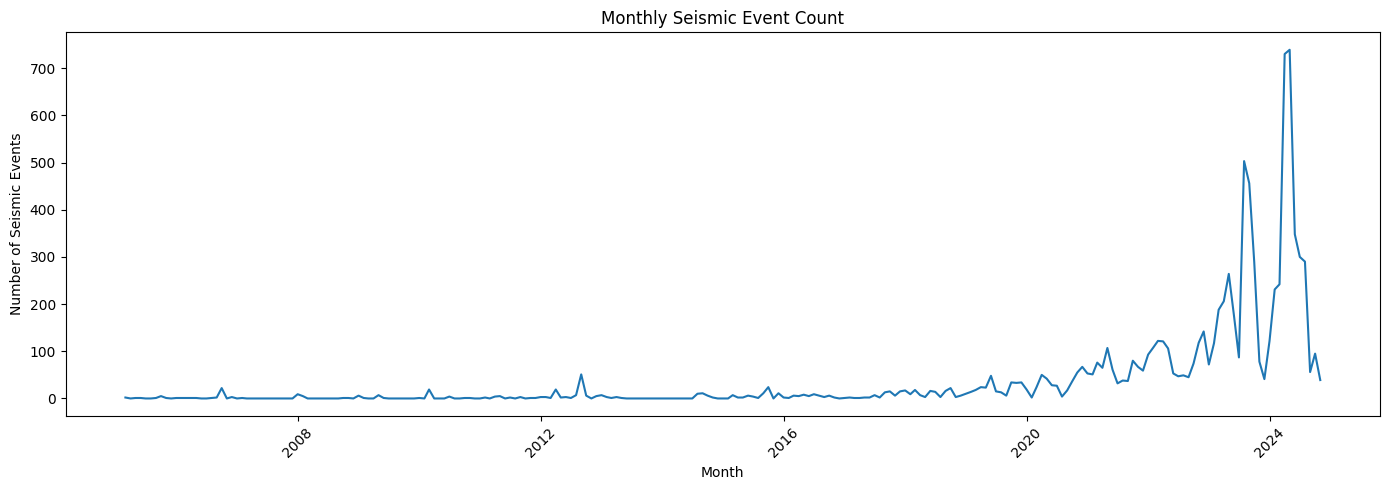

In [210]:
plt.figure(figsize=(14, 5))

plt.plot(
    model_data['Month'],
    model_data['Seismic_Event_Count']
)

plt.title('Monthly Seismic Event Count')
plt.xlabel('Month')
plt.ylabel('Number of Seismic Events')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [211]:
top_activity = (
    model_data[
        ['Month', 'Seismic_Event_Count']
    ]
    .sort_values(
        'Seismic_Event_Count',
        ascending=False
    )
    .head(10)
)

display(top_activity)

,Month,Seismic_Event_Count
230,2024-05-01,739.0
229,2024-04-01,730.0
221,2023-08-01,503.0
222,2023-09-01,456.0
231,2024-06-01,348.0
232,2024-07-01,300.0
233,2024-08-01,290.0
223,2023-10-01,289.0
218,2023-05-01,264.0
228,2024-03-01,242.0


In [212]:
# lowest_nonzero = (
#     model_data[
#         model_data['Seismic_Event_Count'] > 0
#     ][
#         ['Month', 'Seismic_Event_Count']
#     ]
#     .sort_values(
#         'Seismic_Event_Count'
#     )
#     .head(10)
# )

# display(lowest_nonzero)

,Month,Seismic_Event_Count
2,2005-05-01,1.0
3,2005-06-01,1.0
6,2005-09-01,1.0
8,2005-11-01,1.0
11,2006-02-01,1.0
10,2006-01-01,1.0
13,2006-04-01,1.0
12,2006-03-01,1.0
23,2007-02-01,1.0
17,2006-08-01,1.0


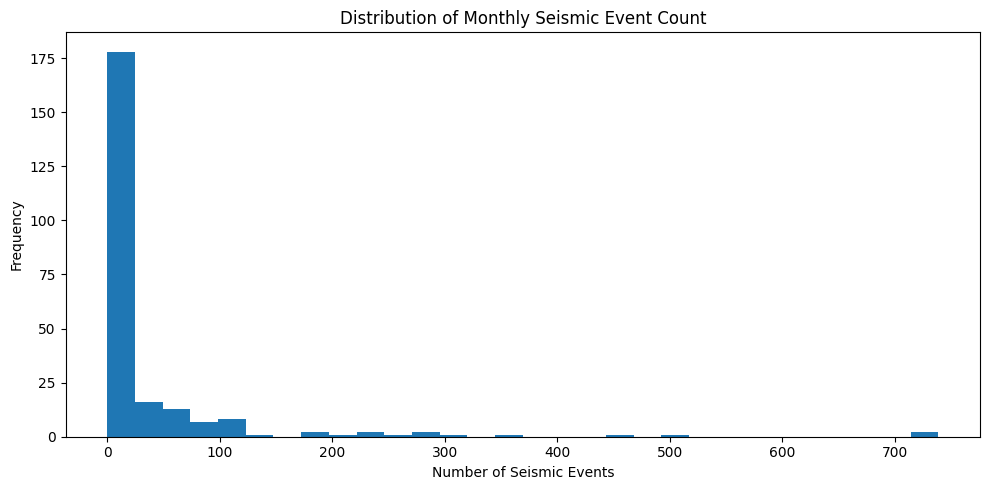

In [213]:
plt.figure(figsize=(10, 5))

plt.hist(
    model_data['Seismic_Event_Count'],
    bins=30
)

plt.title('Distribution of Monthly Seismic Event Count')
plt.xlabel('Number of Seismic Events')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

This histogram shows the distribution of monthly seismic event counts. The x-axis represents the number of seismic events in a month, while the y-axis represents how many months fall within each range. Most months have relatively low seismic activity, while only a few months have very high event counts. Therefore, the distribution is highly concentrated at lower values and has a long tail caused by high-activity months.

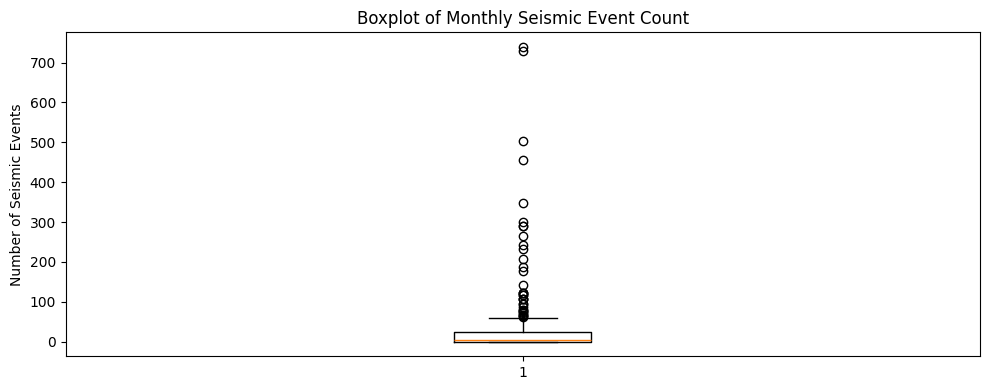

In [214]:
plt.figure(figsize=(10, 4))

plt.boxplot(
    model_data['Seismic_Event_Count']
)

plt.title('Boxplot of Monthly Seismic Event Count')
plt.ylabel('Number of Seismic Events')

plt.tight_layout()
plt.show()

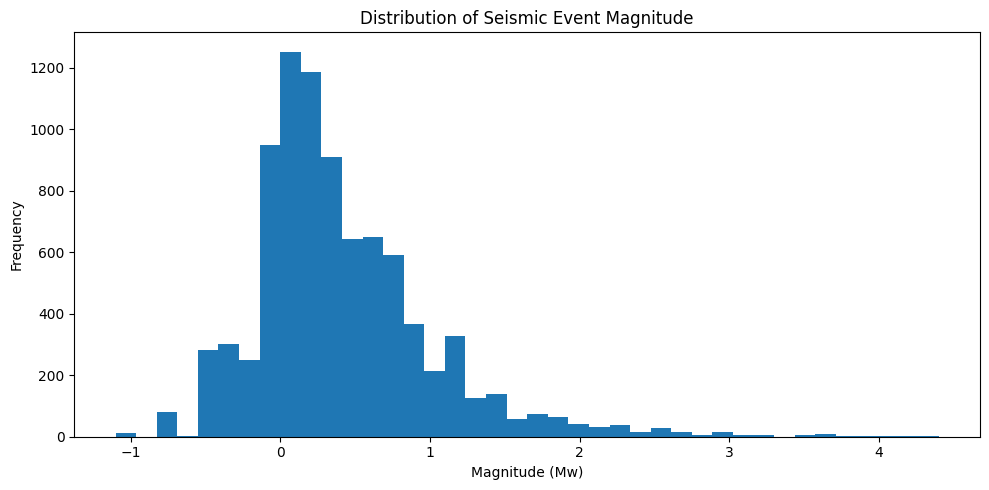

In [333]:
plt.figure(figsize=(10, 5))

plt.hist(
    event_data['Magnitude'].dropna(),
    bins=40
)

plt.title('Distribution of Seismic Event Magnitude')
plt.xlabel('Magnitude (Mw)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

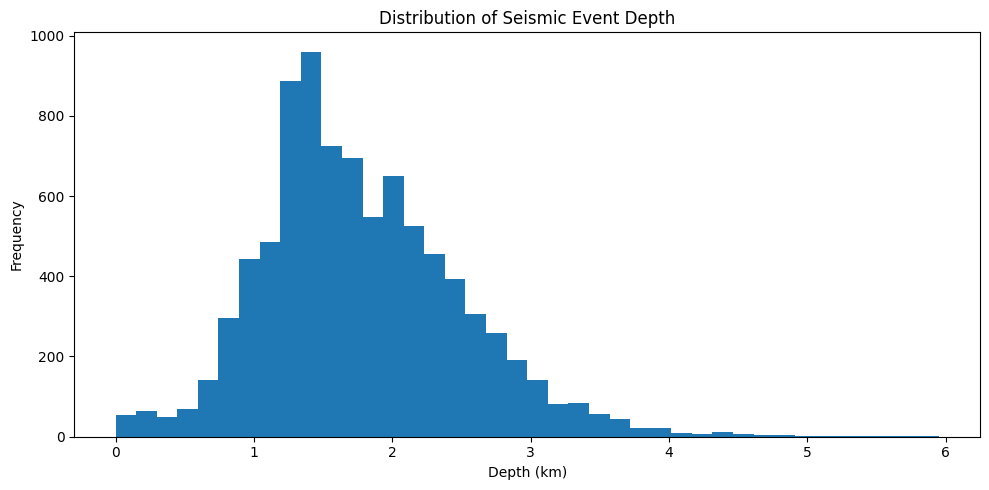

In [335]:
plt.figure(figsize=(10, 5))

plt.hist(
    event_data['Depth'].dropna(),
    bins=40
)

plt.title('Distribution of Seismic Event Depth')
plt.xlabel('Depth (km)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

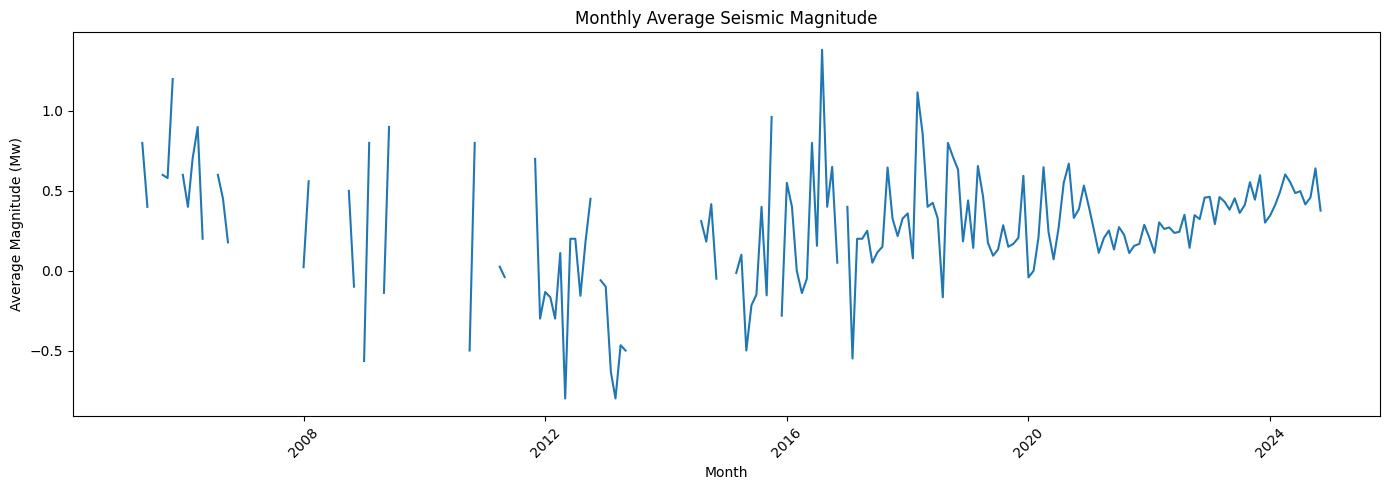

In [217]:
plt.figure(figsize=(14, 5))

plt.plot(
    model_data['Month'],
    model_data['Avg_Magnitude']
)

plt.title('Monthly Average Seismic Magnitude')
plt.xlabel('Month')
plt.ylabel('Average Magnitude (Mw)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

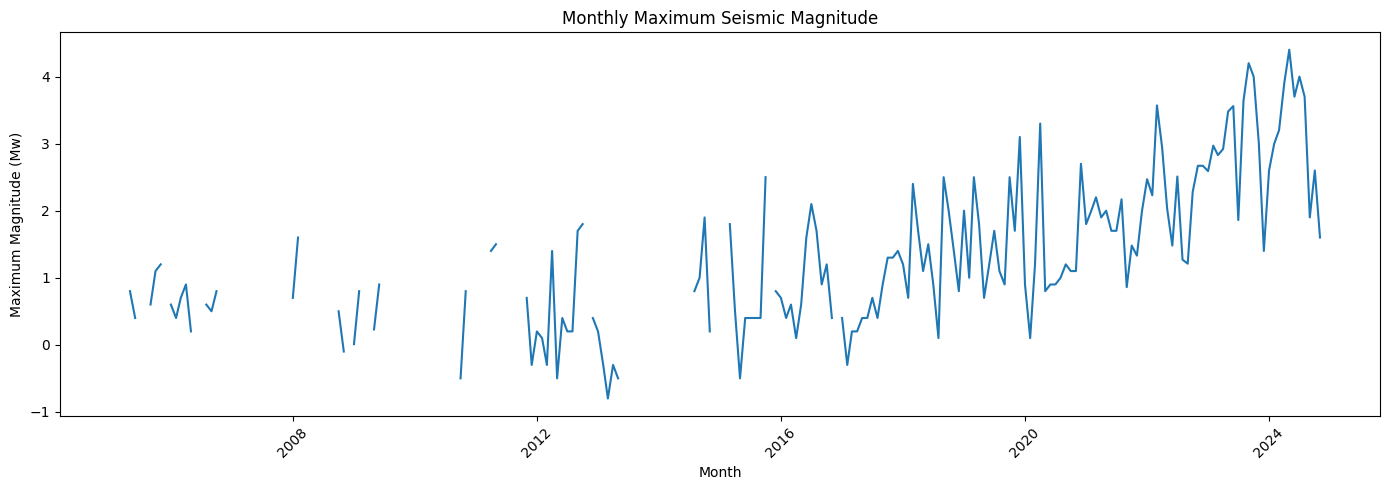

In [218]:
plt.figure(figsize=(14, 5))

plt.plot(
    model_data['Month'],
    model_data['Max_Magnitude']
)

plt.title('Monthly Maximum Seismic Magnitude')
plt.xlabel('Month')
plt.ylabel('Maximum Magnitude (Mw)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

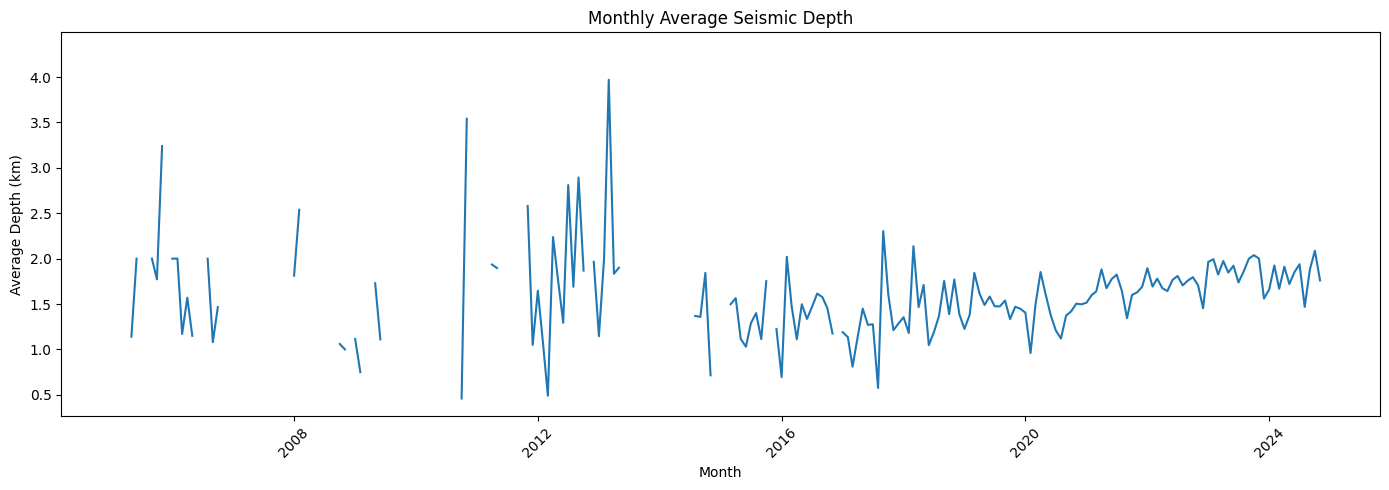

In [219]:
plt.figure(figsize=(14, 5))

plt.plot(
    model_data['Month'],
    model_data['Avg_Depth']
)

plt.title('Monthly Average Seismic Depth')
plt.xlabel('Month')
plt.ylabel('Average Depth (km)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [220]:
correlation = model_data[
    [
        'Seismic_Event_Count',
        'Avg_Magnitude',
        'Max_Magnitude',
        'Avg_Depth',
        'Max_Depth'
    ]
].corr()

display(correlation)

,Seismic_Event_Count,Avg_Magnitude,Max_Magnitude,Avg_Depth,Max_Depth
Seismic_Event_Count,1.000000,0.166959,0.712806,0.139427,0.567095
Avg_Magnitude,0.166959,1.000000,0.498235,0.237558,0.172789
Max_Magnitude,0.712806,0.498235,1.000000,0.225872,0.697916
Avg_Depth,0.139427,0.237558,0.225872,1.000000,0.542588
Max_Depth,0.567095,0.172789,0.697916,0.542588,1.000000


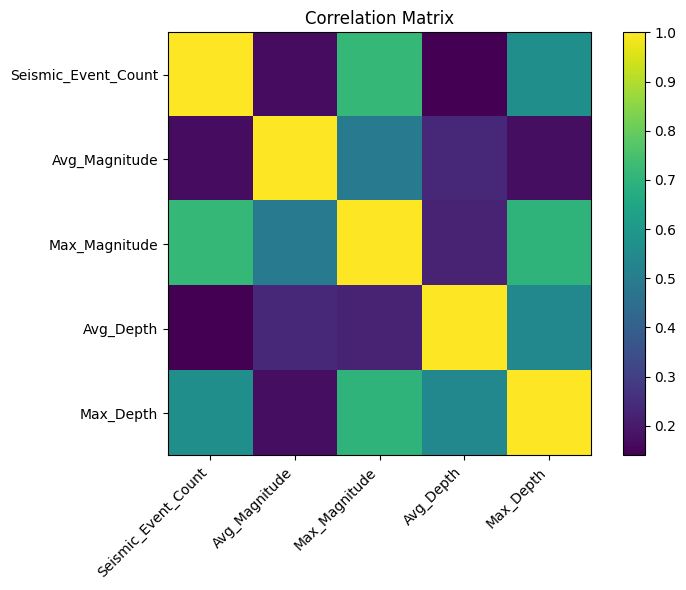

In [221]:
plt.figure(figsize=(8, 6))

plt.imshow(correlation, interpolation='none')

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

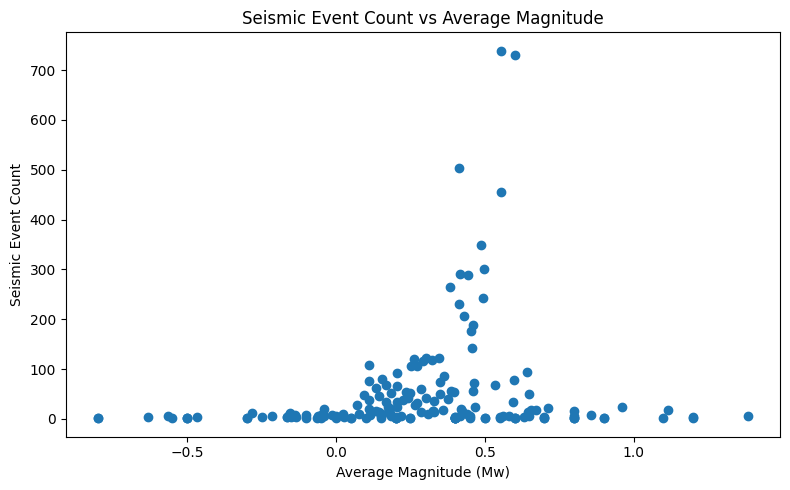

In [222]:
plt.figure(figsize=(8, 5))

plt.scatter(
    model_data['Avg_Magnitude'],
    model_data['Seismic_Event_Count']
)

plt.title('Seismic Event Count vs Average Magnitude')
plt.xlabel('Average Magnitude (Mw)')
plt.ylabel('Seismic Event Count')

plt.tight_layout()
plt.show()

I used a scatter plot to examine the relationship between monthly average magnitude and the number of seismic events

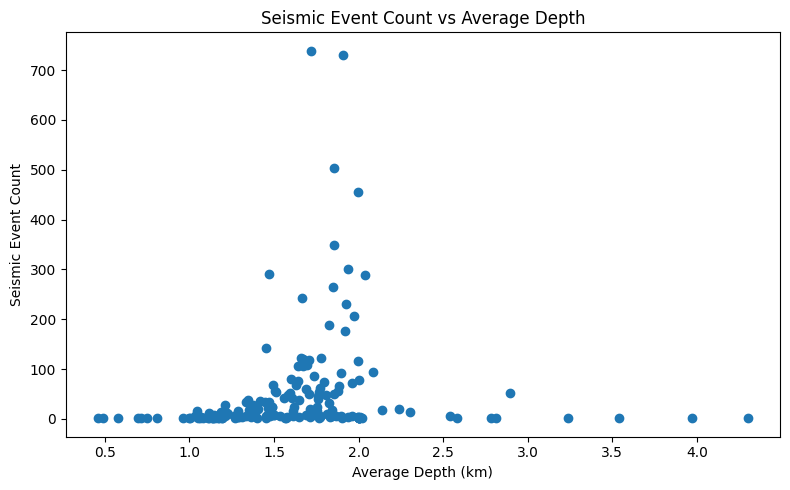

In [223]:
plt.figure(figsize=(8, 5))

plt.scatter(
    model_data['Avg_Depth'],
    model_data['Seismic_Event_Count']
)

plt.title('Seismic Event Count vs Average Depth')
plt.xlabel('Average Depth (km)')
plt.ylabel('Seismic Event Count')

plt.tight_layout()
plt.show()

This examines whether event frequency is associated with average earthquake depth.

In [224]:
yearly_activity = (
    model_data
    .assign(
        Year=model_data['Month'].dt.year
    )
    .groupby('Year')['Seismic_Event_Count']
    .sum()
)

display(yearly_activity)



,Seismic_Event_Count
Year,
2005,11.0
2006,33.0
2007,1.0
2008,16.0
2009,15.0
2010,26.0
2011,18.0
2012,101.0
2013,15.0


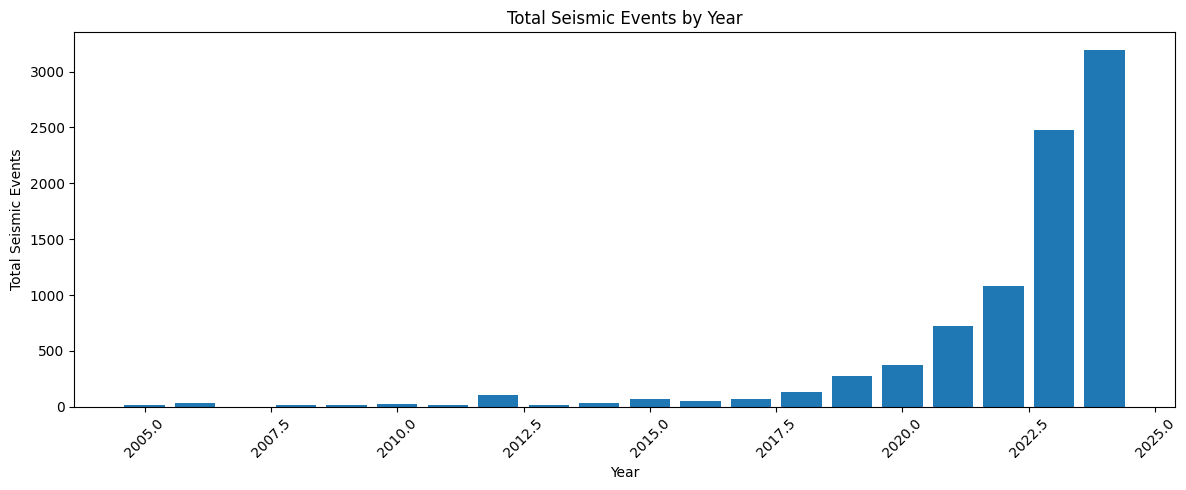

In [225]:
plt.figure(figsize=(12, 5))

plt.bar(
    yearly_activity.index,
    yearly_activity.values
)

plt.title('Total Seismic Events by Year')
plt.xlabel('Year')
plt.ylabel('Total Seismic Events')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

graph clearly shows that seismic activity increases dramatically in the later years, especially around 2022–2024.

The yearly aggregation shows a substantial change in seismic activity over time, with much higher numbers of events in the later years. This indicates temporal variation in the dataset and helps explain why forecasting later high-activity periods is challenging

In [336]:
print("Missing values in the modeling dataset:")

display(model_data.isnull().sum())

Missing values in the modeling dataset:


,0
Month,0
Seismic_Event_Count,0
Avg_Magnitude,66
Max_Magnitude,66
Avg_Depth,66
Max_Depth,66


The missing values in the magnitude and depth features correspond to months with no recorded seismic events. Therefore, these values represent the absence of observations rather than measurements of zero magnitude or zero depth. Missing values will be handled during the preprocessing stage before machine learning.

### EDA Summary

The exploratory analysis shows that seismic activity varies considerably over time, with both low-activity periods and months containing substantially higher numbers of seismic events.

The distribution of monthly event counts also shows the presence of extreme values. Magnitude and depth vary across individual seismic events, while their monthly averages and maximum values change over time.

The analysis also identifies missing aggregated magnitude and depth values in months without recorded seismic events. These values represent the absence of event observations rather than measurements of zero magnitude or depth.

Overall, the EDA indicates that temporal patterns and previous seismic activity should be considered when developing the forecasting models.

# **Part 5: Define the Target and Create the Forecasting Structure**

Now we move from EDA to machine learning preparation.

The objective is to predict the number of seismic events in the following month using information available in the current month.

For example:

March 2005
↓
Information available in March
↓
Predict April 2005 event count



## **5.1 Create the Target**

Our prediction target is the number of seismic events in the following month.

We create this target by shifting the monthly seismic-event count one month backward.

For example:

March 2005 event count → information
April 2005 event count → target

This allows the model to learn how current and previous seismic activity relates to the following month's activity.

In [226]:
ml_data = model_data.copy()

print("Original shape:", ml_data.shape)
display(ml_data.head())

Original shape: (237, 6)


,Month,Seismic_Event_Count,Avg_Magnitude,Max_Magnitude,Avg_Depth,Max_Depth
0,2005-03-01,2.0,-0.065,0.36,1.195,1.39
1,2005-04-01,0.0,NaN,NaN,NaN,NaN
2,2005-05-01,1.0,0.800,0.80,1.140,1.14
3,2005-06-01,1.0,0.400,0.40,2.000,2.00
4,2005-07-01,0.0,NaN,NaN,NaN,NaN


created a copy of the modeling dataset so that feature engineering could be performed without modifying the original cleaned dataset.

In [227]:
ml_data['Target_Next_Month'] = (
    ml_data['Seismic_Event_Count'].shift(-1)
)

In [228]:
display(
    ml_data[
        [
            'Month',
            'Seismic_Event_Count',
            'Target_Next_Month'
        ]
    ].head(15)
)

,Month,Seismic_Event_Count,Target_Next_Month
0,2005-03-01,2.0,0.0
1,2005-04-01,0.0,1.0
2,2005-05-01,1.0,1.0
3,2005-06-01,1.0,0.0
4,2005-07-01,0.0,0.0
5,2005-08-01,0.0,1.0
6,2005-09-01,1.0,5.0
7,2005-10-01,5.0,1.0
8,2005-11-01,1.0,0.0
9,2005-12-01,0.0,1.0


In [338]:
ml_data = ml_data.dropna(
    subset=['Target_Next_Month']
).reset_index(drop=True)

The final month has no following month available, so its target is naturally missing.
We remove that final row.

In [337]:
print("ML dataset shape after creating the target:", ml_data.shape)

ML dataset shape after creating the target: (236, 19)


In [232]:
# check_target = ml_data[
#     [
#         'Month',
#         'Seismic_Event_Count',
#         'Target_Next_Month'
#     ]
# ].copy()

# check_target['Expected_Target'] = (
#     ml_data['Seismic_Event_Count'].shift(-1)
# )

# display(check_target.head(15))

,Month,Seismic_Event_Count,Target_Next_Month,Expected_Target
0,2005-03-01,2.0,0.0,0.0
1,2005-04-01,0.0,1.0,1.0
2,2005-05-01,1.0,1.0,1.0
3,2005-06-01,1.0,0.0,0.0
4,2005-07-01,0.0,0.0,0.0
5,2005-08-01,0.0,1.0,1.0
6,2005-09-01,1.0,5.0,5.0
7,2005-10-01,5.0,1.0,1.0
8,2005-11-01,1.0,0.0,0.0
9,2005-12-01,0.0,1.0,1.0


In [233]:
ml_data['Event_Count_Lag_1'] = (
    ml_data['Seismic_Event_Count'].shift(1)
)

Previous month's event count.

In [234]:
ml_data['Event_Count_Lag_2'] = (
    ml_data['Seismic_Event_Count'].shift(2)
)

Event count from two months ago.


In [235]:
ml_data['Event_Count_Lag_3'] = (
    ml_data['Seismic_Event_Count'].shift(3)
)

Event count from three months ago.


## **5.3 Create Rolling Features**

Lag features use individual previous months.

Rolling features summarize seismic activity over several recent months.

We will create a 3-month rolling mean of the seismic event count.

In [236]:
ml_data['Event_Count_Rolling_Mean_3'] = (
    ml_data['Seismic_Event_Count']
    .rolling(window=3)
    .mean()
)

**6-month rolling average**

In [237]:
# ml_data['Event_Count_Rolling_Mean_6'] = (
#     ml_data['Seismic_Event_Count']
#     .rolling(window=6)
#     .mean()
# )

Important question: Is this leakage?

No, provided our forecasting setup is:

At the end of the current month, predict the next month.

For example:

January + February + March information
→ predict April.

The March value is already known when we make the April prediction.

So this is valid.

### **Why are the rolling features valid?**

The rolling features use information that is available at the time the prediction is made.

For example, when predicting April, the model can use information from January, February, and March because those months have already occurred.

Therefore, the rolling features do not use information from the future target month.

In [238]:
ml_data['Avg_Magnitude_Lag_1'] = (
    ml_data['Avg_Magnitude'].shift(1)
)

ml_data['Max_Magnitude_Lag_1'] = (
    ml_data['Max_Magnitude'].shift(1)
)

ml_data['Avg_Depth_Lag_1'] = (
    ml_data['Avg_Depth'].shift(1)
)

ml_data['Max_Depth_Lag_1'] = (
    ml_data['Max_Depth'].shift(1)
)

### **Why use magnitude and depth lags?**

The previous month's seismic characteristics may contain information about the following month's seismic activity.

We therefore include the previous month's:

- average magnitude,
- maximum magnitude,
- average depth,
- maximum depth.

These features allow the models to consider not only how many events occurred previously, but also characteristics of those events.

In [239]:
display(
    ml_data.head(15)
)

,Month,Seismic_Event_Count,Avg_Magnitude,Max_Magnitude,Avg_Depth,Max_Depth,Target_Next_Month,Event_Count_Lag_1,Event_Count_Lag_2,Event_Count_Lag_3,Event_Count_Rolling_Mean_3,Event_Count_Rolling_Mean_6,Avg_Magnitude_Lag_1,Max_Magnitude_Lag_1,Avg_Depth_Lag_1,Max_Depth_Lag_1
0,2005-03-01,2.0,-0.065,0.36,1.195,1.39,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2005-04-01,0.0,NaN,NaN,NaN,NaN,1.0,2.0,NaN,NaN,NaN,NaN,-0.065,0.36,1.195,1.39
2,2005-05-01,1.0,0.800,0.80,1.140,1.14,1.0,0.0,2.0,NaN,1.000000,NaN,NaN,NaN,NaN,NaN
3,2005-06-01,1.0,0.400,0.40,2.000,2.00,0.0,1.0,0.0,2.0,0.666667,NaN,0.800,0.80,1.140,1.14
4,2005-07-01,0.0,NaN,NaN,NaN,NaN,0.0,1.0,1.0,0.0,0.666667,NaN,0.400,0.40,2.000,2.00
5,2005-08-01,0.0,NaN,NaN,NaN,NaN,1.0,0.0,1.0,1.0,0.333333,0.666667,NaN,NaN,NaN,NaN
6,2005-09-01,1.0,0.600,0.60,2.000,2.00,5.0,0.0,0.0,1.0,0.333333,0.500000,NaN,NaN,NaN,NaN
7,2005-10-01,5.0,0.580,1.10,1.772,2.28,1.0,1.0,0.0,0.0,2.000000,1.333333,0.600,0.60,2.000,2.00
8,2005-11-01,1.0,1.200,1.20,3.240,3.24,0.0,5.0,1.0,0.0,2.333333,1.333333,0.580,1.10,1.772,2.28
9,2005-12-01,0.0,NaN,NaN,NaN,NaN,1.0,1.0,5.0,1.0,2.000000,1.166667,1.200,1.20,3.240,3.24


In [240]:
print("Missing values:")
print(ml_data.isnull().sum())

Missing values:
Month                          0
Seismic_Event_Count            0
Avg_Magnitude                 66
Max_Magnitude                 66
Avg_Depth                     66
Max_Depth                     66
Target_Next_Month              0
Event_Count_Lag_1              1
Event_Count_Lag_2              2
Event_Count_Lag_3              3
Event_Count_Rolling_Mean_3     2
Event_Count_Rolling_Mean_6     5
Avg_Magnitude_Lag_1           67
Max_Magnitude_Lag_1           67
Avg_Depth_Lag_1               67
Max_Depth_Lag_1               67
dtype: int64


In [241]:
print(
    "Chronological order:",
    ml_data['Month'].is_monotonic_increasing
)

Chronological order: True


In [339]:
print("Final ML dataset:")
print("Rows:", ml_data.shape[0])
print("Columns:", ml_data.shape[1])

print("\nFeatures created:")
print(ml_data.columns.tolist())

Final ML dataset:
Rows: 236
Columns: 19

Features created:
['Month', 'Seismic_Event_Count', 'Avg_Magnitude', 'Max_Magnitude', 'Avg_Depth', 'Max_Depth', 'Target_Next_Month', 'Event_Count_Lag_1', 'Event_Count_Lag_2', 'Event_Count_Lag_3', 'Event_Count_Rolling_Mean_3', 'Event_Count_Rolling_Mean_6', 'Avg_Magnitude_Lag_1', 'Max_Magnitude_Lag_1', 'Avg_Depth_Lag_1', 'Max_Depth_Lag_1', 'Year', 'Month_Number', 'Time_Index']


# **Part 6: Chronological Train-Test Split**

The dataset is divided into training and testing periods while preserving the chronological order.

We use approximately:

- 80% of the observations for training
- 20% of the observations for final testing

The data is not randomly shuffled because this is a time-series forecasting problem. The model should only learn from the past and be evaluated on future observations.

In [340]:
train_size = int(len(ml_data) * 0.80)

print("Total observations:", len(ml_data))
print("Training observations:", train_size)
print("Testing observations:", len(ml_data) - train_size)

Total observations: 236
Training observations: 188
Testing observations: 48


In [244]:
train_data = ml_data.iloc[:train_size].copy()
test_data = ml_data.iloc[train_size:].copy()

print("Training period:")
print(train_data['Month'].min(), "to", train_data['Month'].max())

print("\nTesting period:")
print(test_data['Month'].min(), "to", test_data['Month'].max())

Training period:
2005-03-01 00:00:00 to 2020-10-01 00:00:00

Testing period:
2020-11-01 00:00:00 to 2024-10-01 00:00:00


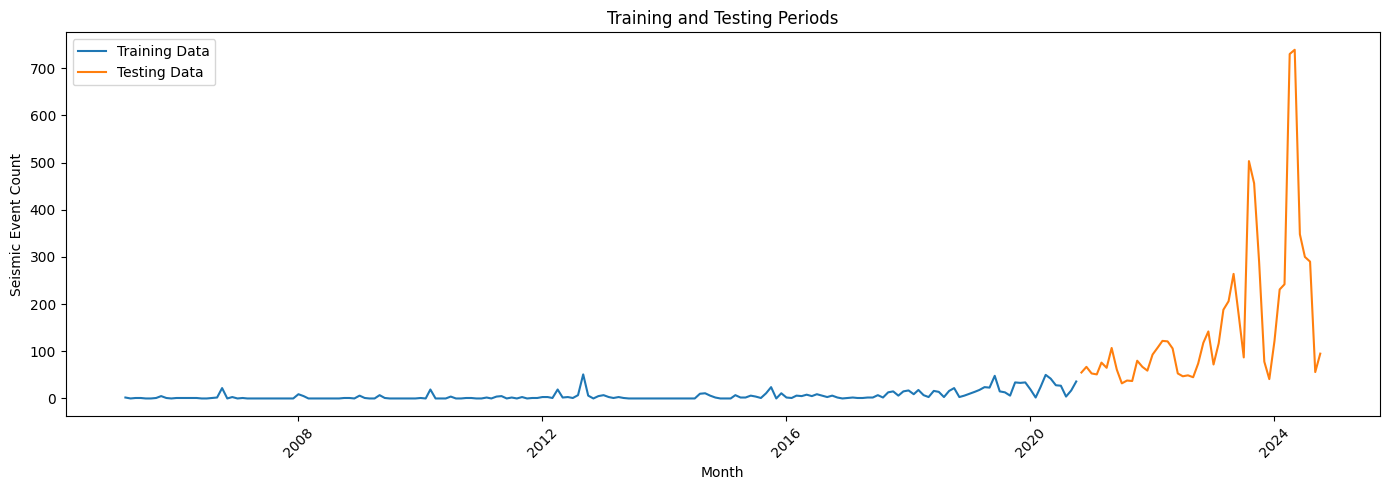

In [245]:
plt.figure(figsize=(14, 5))

plt.plot(
    train_data['Month'],
    train_data['Seismic_Event_Count'],
    label='Training Data'
)

plt.plot(
    test_data['Month'],
    test_data['Seismic_Event_Count'],
    label='Testing Data'
)

plt.title('Training and Testing Periods')
plt.xlabel('Month')
plt.ylabel('Seismic Event Count')
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [246]:
target = 'Target_Next_Month'


features = [
    'Seismic_Event_Count',
    'Avg_Magnitude',
    'Max_Magnitude',
    'Avg_Depth',
    'Max_Depth',
    'Event_Count_Lag_1',
    'Event_Count_Lag_2',
    'Event_Count_Lag_3',
    'Event_Count_Rolling_Mean_3',
    'Avg_Magnitude_Lag_1',
    'Max_Magnitude_Lag_1',
    'Avg_Depth_Lag_1',
    'Max_Depth_Lag_1'
]

In [247]:
X_train = train_data[features]
y_train = train_data[target]

X_test = test_data[features]
y_test = test_data[target]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (188, 13)
y_train: (188,)
X_test: (48, 13)
y_test: (48,)


In [248]:
print("Training missing values:")
print(X_train.isnull().sum())

print("\nTesting missing values:")
print(X_test.isnull().sum())

Training missing values:
Seismic_Event_Count            0
Avg_Magnitude                 66
Max_Magnitude                 66
Avg_Depth                     66
Max_Depth                     66
Event_Count_Lag_1              1
Event_Count_Lag_2              2
Event_Count_Lag_3              3
Event_Count_Rolling_Mean_3     2
Avg_Magnitude_Lag_1           67
Max_Magnitude_Lag_1           67
Avg_Depth_Lag_1               67
Max_Depth_Lag_1               67
dtype: int64

Testing missing values:
Seismic_Event_Count           0
Avg_Magnitude                 0
Max_Magnitude                 0
Avg_Depth                     0
Max_Depth                     0
Event_Count_Lag_1             0
Event_Count_Lag_2             0
Event_Count_Lag_3             0
Event_Count_Rolling_Mean_3    0
Avg_Magnitude_Lag_1           0
Max_Magnitude_Lag_1           0
Avg_Depth_Lag_1               0
Max_Depth_Lag_1               0
dtype: int64


Do not manually fill these here.

We will handle them through the preprocessing pipeline.

In [249]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

## **Part 7: Build Our Baseline**

Before we train Linear Regression, Random Forest, etc., we need a baseline.

This is very important academically.

We need to answer:

"Is our machine-learning model actually better than a simple prediction?"

Otherwise a fancy model could produce impressive-looking numbers while accomplishing approximately nothing. A surprisingly common human tradition.

**7.1 What Is Our Baseline?**

We'll use a very simple forecasting rule:

Predict next month's event count as equal to the current month's event count.

So:

Current month = 50 events
        ↓
Prediction for next month = 50

This is called a naive/persistence forecast.

**7.2 Create the Baseline Prediction**

In [250]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Naive baseline:
# predict next month's event count using current month's event count

baseline_predictions = test_data['Seismic_Event_Count'].values
baseline_actual = test_data['Target_Next_Month'].values

print("Baseline predictions:")
print(baseline_predictions[:10])

print("\nActual target values:")
print(baseline_actual[:10])

Baseline predictions:
[ 55.  67.  53.  51.  76.  65. 107.  61.  32.  38.]

Actual target values:
[ 67.  53.  51.  76.  65. 107.  61.  32.  38.  37.]


In [251]:
baseline_mae = mean_absolute_error(
    baseline_actual,
    baseline_predictions
)

print("Baseline MAE:", baseline_mae)

Baseline MAE: 68.45833333333333


In [252]:
baseline_rmse = np.sqrt(
    mean_squared_error(
        baseline_actual,
        baseline_predictions
    )
)

print("Baseline RMSE:", baseline_rmse)

Baseline RMSE: 126.47463513817043


In [253]:
baseline_r2 = r2_score(
    baseline_actual,
    baseline_predictions
)

print("Baseline R²:", baseline_r2)

Baseline R²: 0.3861487724441186


In [254]:
baseline_results = pd.DataFrame({
    'Model': ['Naive Baseline'],
    'MAE': [baseline_mae],
    'RMSE': [baseline_rmse],
    'R2': [baseline_r2]
})

display(baseline_results)

,Model,MAE,RMSE,R2
0,Naive Baseline,68.458333,126.474635,0.386149


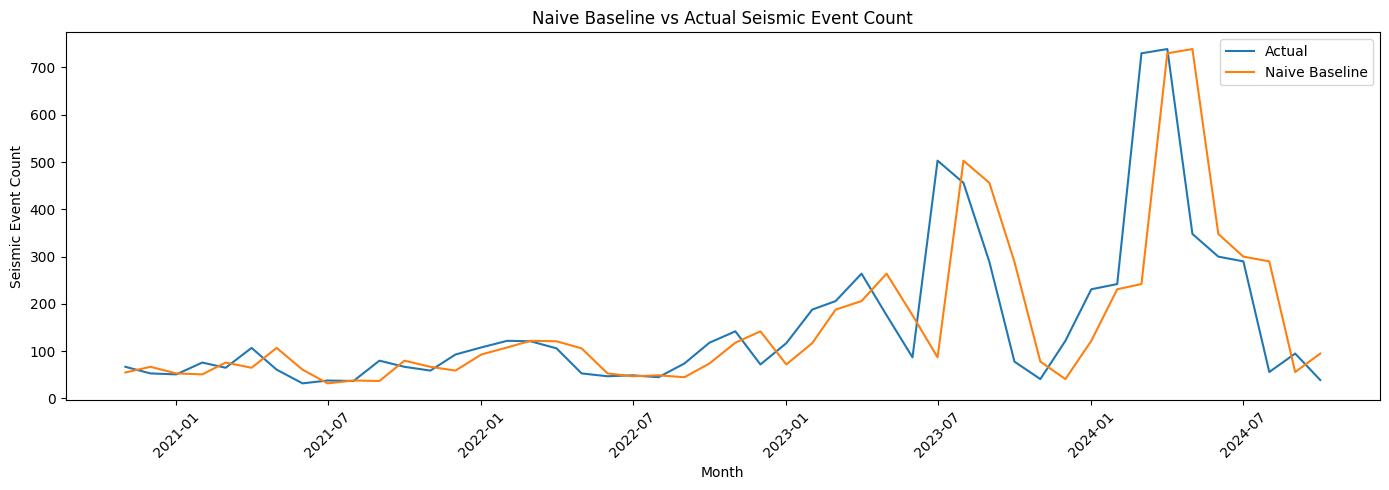

In [255]:
plt.figure(figsize=(14, 5))

plt.plot(
    test_data['Month'],
    baseline_actual,
    label='Actual'
)

plt.plot(
    test_data['Month'],
    baseline_predictions,
    label='Naive Baseline'
)

plt.title('Naive Baseline vs Actual Seismic Event Count')
plt.xlabel('Month')
plt.ylabel('Seismic Event Count')

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [256]:
training_mean = y_train.mean()

mean_predictions = np.full(
    len(y_test),
    training_mean
)

mean_mae = mean_absolute_error(
    y_test,
    mean_predictions
)

mean_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        mean_predictions
    )
)

mean_r2 = r2_score(
    y_test,
    mean_predictions
)

print("Historical Mean Baseline")
print("Prediction value:", training_mean)
print("MAE:", mean_mae)
print("RMSE:", mean_rmse)
print("R2:", mean_r2)

Historical Mean Baseline
Prediction value: 6.175531914893617
MAE: 150.90780141843973
RMSE: 220.97810808125192
R2: -0.87393602509568


In [257]:
baseline_comparison = pd.DataFrame({
    'Model': [
        'Historical Mean',
        'Naive Previous Month'
    ],
    'MAE': [
        mean_mae,
        baseline_mae
    ],
    'RMSE': [
        mean_rmse,
        baseline_rmse
    ],
    'R2': [
        mean_r2,
        baseline_r2
    ]
})

display(baseline_comparison)

,Model,MAE,RMSE,R2
0,Historical Mean,150.907801,220.978108,-0.873936
1,Naive Previous Month,68.458333,126.474635,0.386149


# **Part 8: Preprocessing + First ML Model**

Now we're finally going to train our first real machine-learning model.

We'll start with:

**Linear Regression**

Why start there?

Because it's simple, interpretable, and gives us a strong reference point before we move to more complicated models.

Our workflow will be:

X_train
   ↓
Imputation
   ↓
Scaling
   ↓
Linear Regression
   ↓
Predictions
   ↓
MAE / RMSE / R²
   ↓
Compare with baseline

**8.1 Import the required tools**

In [258]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression


linear_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

In [259]:
linear_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()), ('model', LinearRegression())])

In [260]:
linear_predictions = linear_pipeline.predict(
    X_test
)

print("First 10 predictions:")
print(linear_predictions[:10])

print("\nFirst 10 actual values:")
print(y_test.values[:10])

First 10 predictions:
[34.78231795 41.31639576 41.70992668 49.41852227 63.6731141  51.57664785
 73.2142581  58.96856763 41.47223765 53.64921565]

First 10 actual values:
[ 67.  53.  51.  76.  65. 107.  61.  32.  38.  37.]


In [261]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R²:", linear_r2)

Linear Regression
MAE: 77.26707340669465
RMSE: 133.9217498268394
R²: 0.31173055703593355


In [262]:
linear_results = pd.DataFrame({
    'Model': [
        'Naive Previous Month',
        'Linear Regression'
    ],
    'MAE': [
        baseline_mae,
        linear_mae
    ],
    'RMSE': [
        baseline_rmse,
        linear_rmse
    ],
    'R2': [
        baseline_r2,
        linear_r2
    ]
})

display(linear_results)

,Model,MAE,RMSE,R2
0,Naive Previous Month,68.458333,126.474635,0.386149
1,Linear Regression,77.267073,133.921750,0.311731


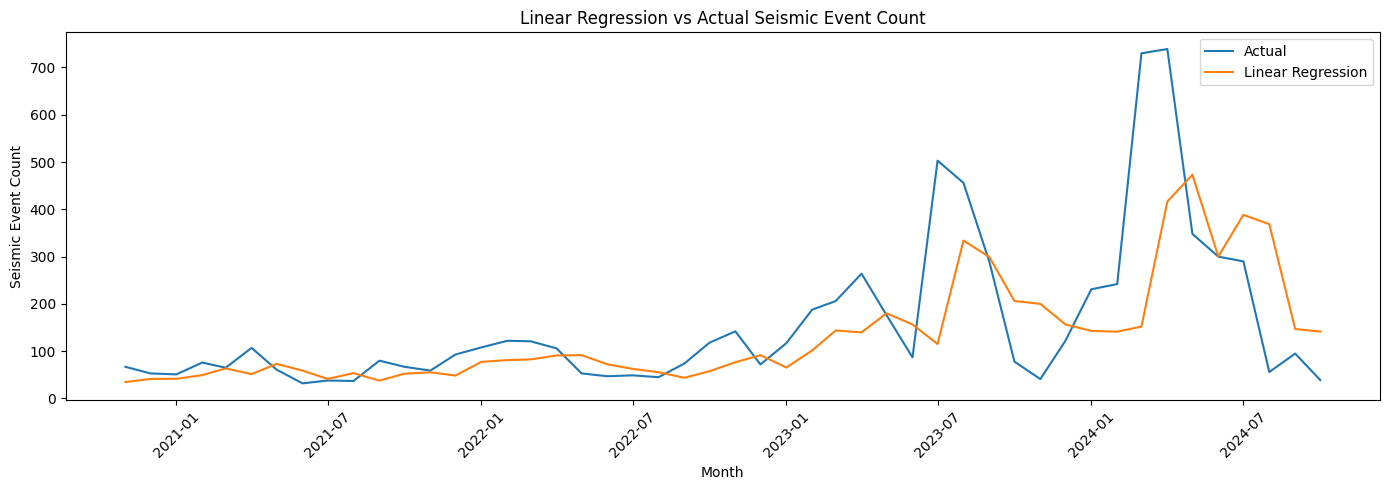

In [263]:
plt.figure(figsize=(14, 5))

plt.plot(
    test_data['Month'],
    y_test,
    label='Actual'
)

plt.plot(
    test_data['Month'],
    linear_predictions,
    label='Linear Regression'
)

plt.title('Linear Regression vs Actual Seismic Event Count')
plt.xlabel('Month')
plt.ylabel('Seismic Event Count')

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Part 9: Ridge Regression**

Now we'll try Ridge Regression.

Why Ridge?

Our features are related to each other:

Event Count
Lag 1
Lag 2
Rolling Mean

and:

Avg Magnitude
Max Magnitude
Avg Depth
Max Depth

Some of these can be correlated.

Ridge Regression adds regularization, which helps control overly large coefficients.

Conceptually:

Linear Regression
       ↓
fits the data

Ridge Regression
       ↓
fits the data
+
controls coefficient size

In [264]:
from sklearn.linear_model import Ridge

In [265]:
ridge_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

In [266]:
ridge_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()), ('model', Ridge())])

In [267]:
ridge_predictions = ridge_pipeline.predict(
    X_test
)

print("First 10 Ridge predictions:")
print(ridge_predictions[:10])

print("\nFirst 10 actual values:")
print(y_test.values[:10])

First 10 Ridge predictions:
[34.5841925  41.25782018 41.65579909 49.33118573 63.49171034 51.52272945
 73.00260506 58.91348064 41.57386592 53.59647156]

First 10 actual values:
[ 67.  53.  51.  76.  65. 107.  61.  32.  38.  37.]


In [268]:
ridge_mae = mean_absolute_error(
    y_test,
    ridge_predictions
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ridge_predictions
    )
)

ridge_r2 = r2_score(
    y_test,
    ridge_predictions
)

print("Ridge Regression")
print("MAE:", ridge_mae)
print("RMSE:", ridge_rmse)
print("R²:", ridge_r2)

Ridge Regression
MAE: 77.37345547227969
RMSE: 134.09365018522723
R²: 0.30996251417309684


In [269]:
model_comparison = pd.DataFrame({
    'Model': [
        'Historical Mean',
        'Naive Previous Month',
        'Linear Regression',
        'Ridge Regression'
    ],
    'MAE': [
        mean_mae,
        baseline_mae,
        linear_mae,
        ridge_mae
    ],
    'RMSE': [
        mean_rmse,
        baseline_rmse,
        linear_rmse,
        ridge_rmse
    ],
    'R2': [
        mean_r2,
        baseline_r2,
        linear_r2,
        ridge_r2
    ]
})

display(model_comparison)

,Model,MAE,RMSE,R2
0,Historical Mean,150.907801,220.978108,-0.873936
1,Naive Previous Month,68.458333,126.474635,0.386149
2,Linear Regression,77.267073,133.921750,0.311731
3,Ridge Regression,77.373455,134.093650,0.309963


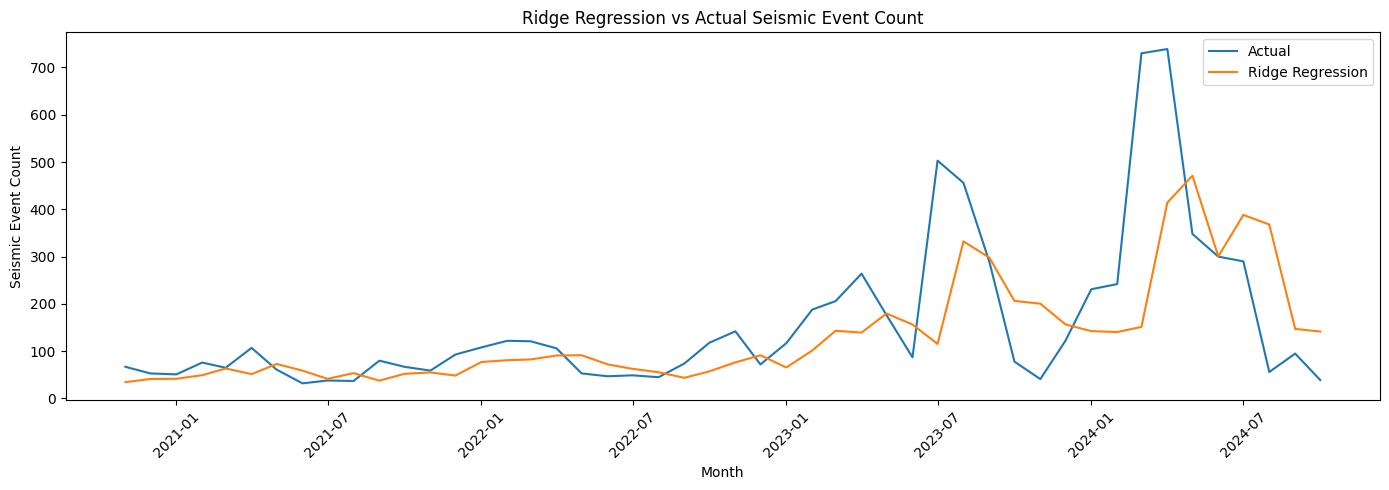

In [270]:
plt.figure(figsize=(14, 5))

plt.plot(
    test_data['Month'],
    y_test,
    label='Actual'
)

plt.plot(
    test_data['Month'],
    ridge_predictions,
    label='Ridge Regression'
)

plt.title('Ridge Regression vs Actual Seismic Event Count')
plt.xlabel('Month')
plt.ylabel('Seismic Event Count')

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Part 10: Random Forest Regression**

Random Forest is a good next step because it can learn nonlinear relationships and interactions between:

recent event counts
lagged event counts
rolling activity
magnitude
depth

without assuming everything follows a straight line.

We'll keep the same train/test split and the same evaluation metrics, so the comparison remains fair.

In [271]:
from sklearn.ensemble import RandomForestRegressor

In [272]:
rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        max_depth=None,
        min_samples_leaf=2
    ))
])

In [273]:
rf_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 RandomForestRegressor(min_samples_leaf=2, n_estimators=300,
                                       random_state=42))])

In [274]:
rf_predictions = rf_pipeline.predict(
    X_test
)

print("First 10 Random Forest predictions:")
print(rf_predictions[:10])

print("\nFirst 10 actual values:")
print(y_test.values[:10])

First 10 Random Forest predictions:
[23.86564815 24.68727778 31.09682937 25.51750794 24.94089683 24.02440476
 25.17337302 24.83774603 23.71564286 25.47634524]

First 10 actual values:
[ 67.  53.  51.  76.  65. 107.  61.  32.  38.  37.]


In [275]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest Regression")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

Random Forest Regression
MAE: 131.54586827601415
RMSE: 208.11367104346286
R²: -0.6621012587566226


In [276]:
model_comparison = pd.DataFrame({
    'Model': [
        'Historical Mean',
        'Naive Previous Month',
        'Linear Regression',
        'Ridge Regression',
        'Random Forest'
    ],
    'MAE': [
        mean_mae,
        baseline_mae,
        linear_mae,
        ridge_mae,
        rf_mae
    ],
    'RMSE': [
        mean_rmse,
        baseline_rmse,
        linear_rmse,
        ridge_rmse,
        rf_rmse
    ],
    'R2': [
        mean_r2,
        baseline_r2,
        linear_r2,
        ridge_r2,
        rf_r2
    ]
})

display(
    model_comparison.sort_values('MAE')
)

,Model,MAE,RMSE,R2
1,Naive Previous Month,68.458333,126.474635,0.386149
2,Linear Regression,77.267073,133.921750,0.311731
3,Ridge Regression,77.373455,134.093650,0.309963
4,Random Forest,131.545868,208.113671,-0.662101
0,Historical Mean,150.907801,220.978108,-0.873936


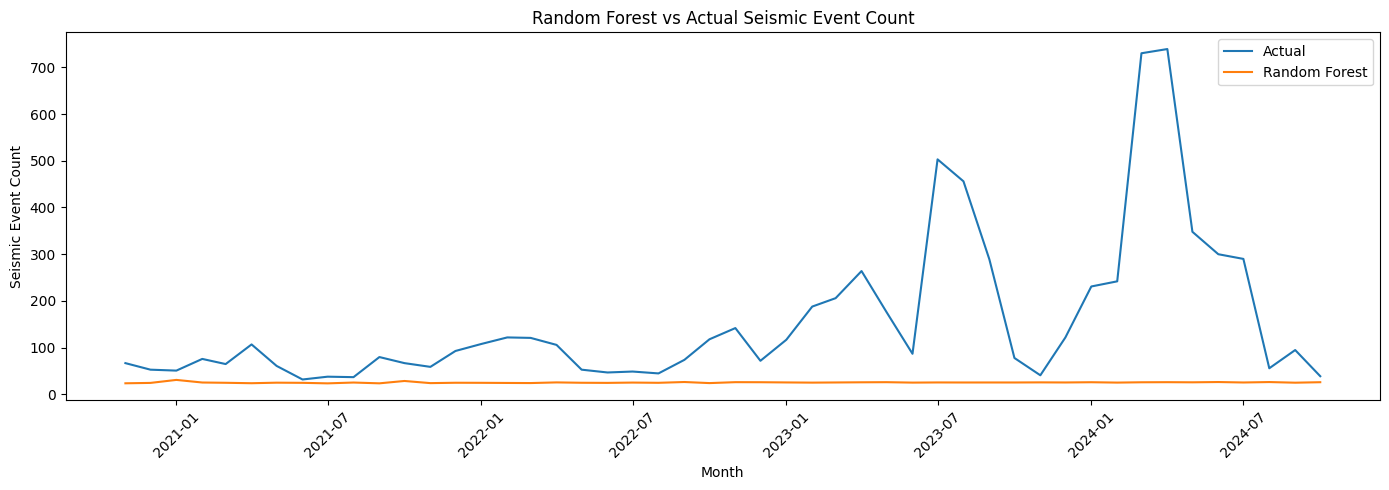

In [277]:
plt.figure(figsize=(14, 5))

plt.plot(
    test_data['Month'],
    y_test,
    label='Actual'
)

plt.plot(
    test_data['Month'],
    rf_predictions,
    label='Random Forest'
)

plt.title('Random Forest vs Actual Seismic Event Count')
plt.xlabel('Month')
plt.ylabel('Seismic Event Count')

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Part 11: Add Temporal Trend Features**

Before testing Gradient Boosting, let's add:

Year
Time_Index

This is important because our problem is fundamentally temporal.

In [278]:
ml_data['Year'] = ml_data['Month'].dt.year

In [279]:
ml_data['Month_Number'] = ml_data['Month'].dt.month

In [280]:
ml_data['Time_Index'] = np.arange(len(ml_data))

In [281]:
display(
    ml_data[
        ['Month', 'Year', 'Month_Number', 'Time_Index']
    ].head(15)
)

,Month,Year,Month_Number,Time_Index
0,2005-03-01,2005,3,0
1,2005-04-01,2005,4,1
2,2005-05-01,2005,5,2
3,2005-06-01,2005,6,3
4,2005-07-01,2005,7,4
5,2005-08-01,2005,8,5
6,2005-09-01,2005,9,6
7,2005-10-01,2005,10,7
8,2005-11-01,2005,11,8
9,2005-12-01,2005,12,9


In [282]:
'Year',
'Month_Number',
'Time_Index'

'Time_Index'

In [283]:
features = [
    'Seismic_Event_Count',
    'Avg_Magnitude',
    'Max_Magnitude',
    'Avg_Depth',
    'Max_Depth',
    'Event_Count_Lag_1',
    'Event_Count_Lag_2',
    'Event_Count_Lag_3',
    'Event_Count_Rolling_Mean_3',
    'Avg_Magnitude_Lag_1',
    'Max_Magnitude_Lag_1',
    'Avg_Depth_Lag_1',
    'Max_Depth_Lag_1',
    'Year',
    'Month_Number',
    'Time_Index'
]

In [284]:
train_data = ml_data.iloc[:train_size].copy()
test_data = ml_data.iloc[train_size:].copy()

X_train = train_data[features]
y_train = train_data[target]

X_test = test_data[features]
y_test = test_data[target]

In [285]:
ml_data['Year'] = ml_data['Month'].dt.year
ml_data['Month_Number'] = ml_data['Month'].dt.month
ml_data['Time_Index'] = np.arange(len(ml_data))

print(
    ml_data[
        ['Month', 'Year', 'Month_Number', 'Time_Index']
    ].head()
)

       Month  Year  Month_Number  Time_Index
0 2005-03-01  2005             3           0
1 2005-04-01  2005             4           1
2 2005-05-01  2005             5           2
3 2005-06-01  2005             6           3
4 2005-07-01  2005             7           4


In [286]:
train_data = ml_data.iloc[:train_size].copy()
test_data = ml_data.iloc[train_size:].copy()

print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)

Train shape: (188, 19)
Test shape: (48, 19)


In [287]:
X_train = train_data[features]
y_train = train_data[target]

X_test = test_data[features]
y_test = test_data[target]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (188, 16)
y_train: (188,)
X_test: (48, 16)
y_test: (48,)


In [288]:
print("New temporal features:")
print(
    train_data[
        ['Year', 'Month_Number', 'Time_Index']
    ].head()
)

New temporal features:
   Year  Month_Number  Time_Index
0  2005             3           0
1  2005             4           1
2  2005             5           2
3  2005             6           3
4  2005             7           4


**Part 12: Re-run the models with the new temporal features.**

In [289]:
linear_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

In [290]:
linear_pipeline.fit(X_train, y_train)

linear_predictions = linear_pipeline.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_predictions)
)
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression with Temporal Features")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R²:", linear_r2)

Linear Regression with Temporal Features
MAE: 77.0114225800887
RMSE: 139.1072875574649
R²: 0.2573981563597152


In [291]:
from sklearn.ensemble import GradientBoostingRegressor

In [292]:
gb_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.03,
        max_depth=2,
        random_state=42
    ))
])

In [293]:
gb_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.03, max_depth=2,
                                           n_estimators=200,
                                           random_state=42))])

In [294]:
gb_predictions = gb_pipeline.predict(
    X_test
)

print("First 10 Gradient Boosting predictions:")
print(gb_predictions[:10])

print("\nFirst 10 actual values:")
print(y_test.values[:10])

First 10 Gradient Boosting predictions:
[48.15174785 34.43056874 33.93498183 23.43984936 23.69648807 23.69648807
 23.32750448 23.43984936 23.32750448 23.43261523]

First 10 actual values:
[ 67.  53.  51.  76.  65. 107.  61.  32.  38.  37.]


In [295]:
gb_mae = mean_absolute_error(
    y_test,
    gb_predictions
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gb_predictions
    )
)

gb_r2 = r2_score(
    y_test,
    gb_predictions
)

print("Gradient Boosting Regression")
print("MAE:", gb_mae)
print("RMSE:", gb_rmse)
print("R²:", gb_r2)

Gradient Boosting Regression
MAE: 131.25917283686962
RMSE: 208.31481187485923
R²: -0.6653156366008066


In [296]:
model_comparison = pd.DataFrame({
    'Model': [
        'Historical Mean',
        'Naive Previous Month',
        'Linear Regression',
        'Ridge Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'MAE': [
        mean_mae,
        baseline_mae,
        linear_mae,
        ridge_mae,
        rf_mae,
        gb_mae
    ],
    'RMSE': [
        mean_rmse,
        baseline_rmse,
        linear_rmse,
        ridge_rmse,
        rf_rmse,
        gb_rmse
    ],
    'R2': [
        mean_r2,
        baseline_r2,
        linear_r2,
        ridge_r2,
        rf_r2,
        gb_r2
    ]
})

display(
    model_comparison.sort_values('MAE')
)

,Model,MAE,RMSE,R2
1,Naive Previous Month,68.458333,126.474635,0.386149
2,Linear Regression,77.011423,139.107288,0.257398
3,Ridge Regression,77.373455,134.093650,0.309963
5,Gradient Boosting,131.259173,208.314812,-0.665316
4,Random Forest,131.545868,208.113671,-0.662101
0,Historical Mean,150.907801,220.978108,-0.873936


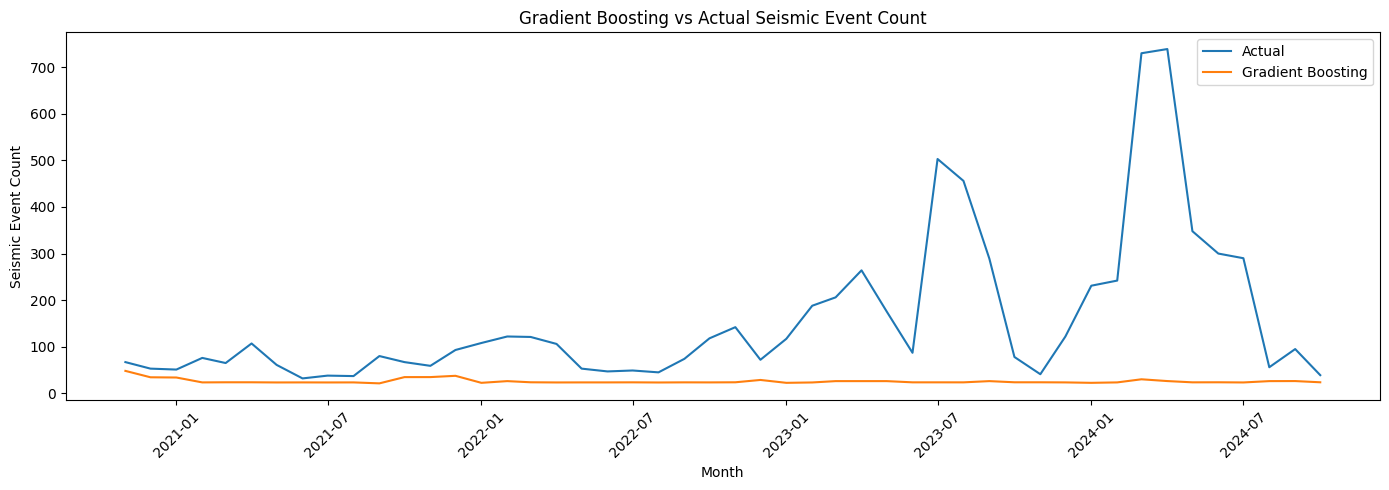

In [297]:
plt.figure(figsize=(14, 5))

plt.plot(
    test_data['Month'],
    y_test,
    label='Actual'
)

plt.plot(
    test_data['Month'],
    gb_predictions,
    label='Gradient Boosting'
)

plt.title(
    'Gradient Boosting vs Actual Seismic Event Count'
)

plt.xlabel('Month')
plt.ylabel('Seismic Event Count')

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Part 13.1: Create a Simple Time-Series Baseline Evaluation**

In [298]:
from sklearn.model_selection import TimeSeriesSplit

In [299]:
# ==========================================
# PART 13: TIME-SERIES CROSS-VALIDATION
# ==========================================

# Use only the training/development data.
# The final test set (Nov 2020 - Oct 2024) remains untouched.

tscv_train = TimeSeriesSplit(n_splits=5)

correct_cv_results = []

for fold, (train_idx, val_idx) in enumerate(
    tscv_train.split(train_data),
    start=1
):

    # Create chronological training and validation folds
    train_fold = train_data.iloc[train_idx]
    val_fold = train_data.iloc[val_idx]

    # Naive baseline:
    # Current month's event count predicts next month's event count
    naive_predictions = val_fold['Seismic_Event_Count'].values
    actual_values = val_fold['Target_Next_Month'].values

    # Evaluation metrics
    fold_mae = mean_absolute_error(
        actual_values,
        naive_predictions
    )

    fold_rmse = np.sqrt(
        mean_squared_error(
            actual_values,
            naive_predictions
        )
    )

    fold_r2 = r2_score(
        actual_values,
        naive_predictions
    )

    # Store results
    correct_cv_results.append({
        'Fold': fold,
        'MAE': fold_mae,
        'RMSE': fold_rmse,
        'R2': fold_r2
    })


# Convert results into DataFrame
correct_cv_results = pd.DataFrame(
    correct_cv_results
)

# Display fold-by-fold results
print("Time-Series Cross-Validation Results")
display(
    correct_cv_results.style.format({
        'MAE': '{:.2f}',
        'RMSE': '{:.2f}',
        'R2': '{:.3f}'
    })
)


# Calculate average performance
mean_cv_mae = correct_cv_results['MAE'].mean()
mean_cv_rmse = correct_cv_results['RMSE'].mean()
mean_cv_r2 = correct_cv_results['R2'].mean()

print("\nAverage Cross-Validation Performance")
print("Mean MAE:", round(mean_cv_mae, 2))
print("Mean RMSE:", round(mean_cv_rmse, 2))
print("Mean R²:", round(mean_cv_r2, 3))

Time-Series Cross-Validation Results


,Fold,MAE,RMSE,R2
0,1,2.90,5.71,-1.129
1,2,5.97,12.44,-0.796
2,3,1.94,3.42,-0.011
3,4,5.29,7.33,-0.494
4,5,11.74,14.90,-0.066



Average Cross-Validation Performance
Mean MAE: 5.57
Mean RMSE: 8.76
Mean R²: -0.499


In [300]:
# Check chronological train/validation periods

print("Cross-Validation Fold Periods")

for fold, (train_idx, val_idx) in enumerate(
    tscv_train.split(train_data),
    start=1
):

    train_fold = train_data.iloc[train_idx]
    val_fold = train_data.iloc[val_idx]

    print(f"\nFold {fold}")

    print(
        "Training:",
        train_fold['Month'].min(),
        "to",
        train_fold['Month'].max()
    )

    print(
        "Validation:",
        val_fold['Month'].min(),
        "to",
        val_fold['Month'].max()
    )

Cross-Validation Fold Periods

Fold 1
Training: 2005-03-01 00:00:00 to 2007-11-01 00:00:00
Validation: 2007-12-01 00:00:00 to 2010-06-01 00:00:00

Fold 2
Training: 2005-03-01 00:00:00 to 2010-06-01 00:00:00
Validation: 2010-07-01 00:00:00 to 2013-01-01 00:00:00

Fold 3
Training: 2005-03-01 00:00:00 to 2013-01-01 00:00:00
Validation: 2013-02-01 00:00:00 to 2015-08-01 00:00:00

Fold 4
Training: 2005-03-01 00:00:00 to 2015-08-01 00:00:00
Validation: 2015-09-01 00:00:00 to 2018-03-01 00:00:00

Fold 5
Training: 2005-03-01 00:00:00 to 2018-03-01 00:00:00
Validation: 2018-04-01 00:00:00 to 2020-10-01 00:00:00


**Part 14: Cross-Validate Linear Regression**

Now we're going to do something important.

Instead of evaluating our models only on the final 2020–2024 test set, we'll evaluate them using the same five temporal folds.

That gives us a fair comparison.

We'll start with Linear Regression.

**14.1 Create CV results**

In [301]:
# ==========================================
# PART 14: LINEAR REGRESSION
# TIME-SERIES CROSS-VALIDATION
# ==========================================

linear_cv_results = []

for fold, (train_idx, val_idx) in enumerate(
    tscv_train.split(train_data),
    start=1
):

    train_fold = train_data.iloc[train_idx]
    val_fold = train_data.iloc[val_idx]

    X_train_fold = train_fold[features]
    y_train_fold = train_fold[target]

    X_val_fold = val_fold[features]
    y_val_fold = val_fold[target]

    # Create a fresh pipeline for each fold
    linear_cv_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ])

    # Train only on the fold's training data
    linear_cv_pipeline.fit(
        X_train_fold,
        y_train_fold
    )

    # Predict validation period
    predictions = linear_cv_pipeline.predict(
        X_val_fold
    )

    # Calculate metrics
    fold_mae = mean_absolute_error(
        y_val_fold,
        predictions
    )

    fold_rmse = np.sqrt(
        mean_squared_error(
            y_val_fold,
            predictions
        )
    )

    fold_r2 = r2_score(
        y_val_fold,
        predictions
    )

    linear_cv_results.append({
        'Fold': fold,
        'MAE': fold_mae,
        'RMSE': fold_rmse,
        'R2': fold_r2
    })


linear_cv_results = pd.DataFrame(
    linear_cv_results
)

print("Linear Regression - Time-Series CV")

display(
    linear_cv_results.style.format({
        'MAE': '{:.2f}',
        'RMSE': '{:.2f}',
        'R2': '{:.3f}'
    })
)

Linear Regression - Time-Series CV


,Fold,MAE,RMSE,R2
0,1,5.53,7.19,-2.374
1,2,5.29,9.16,0.026
2,3,4.63,5.76,-1.876
3,4,5.43,7.09,-0.398
4,5,13.39,16.82,-0.360


In [302]:
print("Average Linear Regression CV Performance")

print(
    "Mean MAE:",
    round(linear_cv_results['MAE'].mean(), 2)
)

print(
    "Mean RMSE:",
    round(linear_cv_results['RMSE'].mean(), 2)
)

print(
    "Mean R²:",
    round(linear_cv_results['R2'].mean(), 3)
)

Average Linear Regression CV Performance
Mean MAE: 6.85
Mean RMSE: 9.21
Mean R²: -0.996


**Part 15: Ridge Regression Time-Series CV**

Now add a new Part 15

Use exactly the same five folds and the same 16 features. The only difference is the model

In [303]:
# ==========================================
# PART 15: RIDGE REGRESSION
# TIME-SERIES CROSS-VALIDATION
# ==========================================

ridge_cv_results = []

for fold, (train_idx, val_idx) in enumerate(
    tscv_train.split(train_data),
    start=1
):

    train_fold = train_data.iloc[train_idx]
    val_fold = train_data.iloc[val_idx]

    X_train_fold = train_fold[features]
    y_train_fold = train_fold[target]

    X_val_fold = val_fold[features]
    y_val_fold = val_fold[target]

    # Fresh Ridge pipeline for each fold
    ridge_cv_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ])

    # Train
    ridge_cv_pipeline.fit(
        X_train_fold,
        y_train_fold
    )

    # Predict
    predictions = ridge_cv_pipeline.predict(
        X_val_fold
    )

    # Evaluation
    fold_mae = mean_absolute_error(
        y_val_fold,
        predictions
    )

    fold_rmse = np.sqrt(
        mean_squared_error(
            y_val_fold,
            predictions
        )
    )

    fold_r2 = r2_score(
        y_val_fold,
        predictions
    )

    ridge_cv_results.append({
        'Fold': fold,
        'MAE': fold_mae,
        'RMSE': fold_rmse,
        'R2': fold_r2
    })


ridge_cv_results = pd.DataFrame(
    ridge_cv_results
)

print("Ridge Regression - Time-Series CV")

display(
    ridge_cv_results.style.format({
        'MAE': '{:.2f}',
        'RMSE': '{:.2f}',
        'R2': '{:.3f}'
    })
)

Ridge Regression - Time-Series CV


,Fold,MAE,RMSE,R2
0,1,3.42,5.29,-0.826
1,2,4.76,8.99,0.062
2,3,4.59,5.73,-1.846
3,4,5.38,7.02,-0.370
4,5,13.43,16.91,-0.374


In [304]:
print("Average Ridge Regression CV Performance")

print(
    "Mean MAE:",
    round(ridge_cv_results['MAE'].mean(), 2)
)

print(
    "Mean RMSE:",
    round(ridge_cv_results['RMSE'].mean(), 2)
)

print(
    "Mean R²:",
    round(ridge_cv_results['R2'].mean(), 3)
)

Average Ridge Regression CV Performance
Mean MAE: 6.32
Mean RMSE: 8.79
Mean R²: -0.671


**Part 16: Random Forest Time-Series CV**

In [305]:
# ==========================================
# PART 16: RANDOM FOREST REGRESSION
# TIME-SERIES CROSS-VALIDATION
# ==========================================

rf_cv_results = []

for fold, (train_idx, val_idx) in enumerate(
    tscv_train.split(train_data),
    start=1
):

    train_fold = train_data.iloc[train_idx]
    val_fold = train_data.iloc[val_idx]

    X_train_fold = train_fold[features]
    y_train_fold = train_fold[target]

    X_val_fold = val_fold[features]
    y_val_fold = val_fold[target]

    # Fresh Random Forest pipeline for each fold
    rf_cv_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestRegressor(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            random_state=42
        ))
    ])

    # Train
    rf_cv_pipeline.fit(
        X_train_fold,
        y_train_fold
    )

    # Predict
    predictions = rf_cv_pipeline.predict(
        X_val_fold
    )

    # Evaluation
    fold_mae = mean_absolute_error(
        y_val_fold,
        predictions
    )

    fold_rmse = np.sqrt(
        mean_squared_error(
            y_val_fold,
            predictions
        )
    )

    fold_r2 = r2_score(
        y_val_fold,
        predictions
    )

    rf_cv_results.append({
        'Fold': fold,
        'MAE': fold_mae,
        'RMSE': fold_rmse,
        'R2': fold_r2
    })


rf_cv_results = pd.DataFrame(
    rf_cv_results
)

print("Random Forest - Time-Series CV")

display(
    rf_cv_results.style.format({
        'MAE': '{:.2f}',
        'RMSE': '{:.2f}',
        'R2': '{:.3f}'
    })
)

Random Forest - Time-Series CV


,Fold,MAE,RMSE,R2
0,1,2.85,4.94,-0.589
1,2,4.30,9.40,-0.025
2,3,6.96,7.63,-4.042
3,4,4.53,5.94,0.018
4,5,13.80,18.09,-0.573


In [306]:
print("Average Random Forest CV Performance")

print(
    "Mean MAE:",
    round(rf_cv_results['MAE'].mean(), 2)
)

print(
    "Mean RMSE:",
    round(rf_cv_results['RMSE'].mean(), 2)
)

print(
    "Mean R²:",
    round(rf_cv_results['R2'].mean(), 3)
)

Average Random Forest CV Performance
Mean MAE: 6.49
Mean RMSE: 9.2
Mean R²: -1.042


**Part 17: Gradient Boosting Time-Series CV**

Now we'll test our fourth ML model using the same exact five folds.

In [307]:
# ==========================================
# PART 17: GRADIENT BOOSTING REGRESSION
# TIME-SERIES CROSS-VALIDATION
# ==========================================

gb_cv_results = []

for fold, (train_idx, val_idx) in enumerate(
    tscv_train.split(train_data),
    start=1
):

    train_fold = train_data.iloc[train_idx]
    val_fold = train_data.iloc[val_idx]

    X_train_fold = train_fold[features]
    y_train_fold = train_fold[target]

    X_val_fold = val_fold[features]
    y_val_fold = val_fold[target]

    # Fresh Gradient Boosting pipeline for each fold
    gb_cv_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.03,
            max_depth=2,
            random_state=42
        ))
    ])

    # Train
    gb_cv_pipeline.fit(
        X_train_fold,
        y_train_fold
    )

    # Predict
    predictions = gb_cv_pipeline.predict(
        X_val_fold
    )

    # Evaluation
    fold_mae = mean_absolute_error(
        y_val_fold,
        predictions
    )

    fold_rmse = np.sqrt(
        mean_squared_error(
            y_val_fold,
            predictions
        )
    )

    fold_r2 = r2_score(
        y_val_fold,
        predictions
    )

    gb_cv_results.append({
        'Fold': fold,
        'MAE': fold_mae,
        'RMSE': fold_rmse,
        'R2': fold_r2
    })


gb_cv_results = pd.DataFrame(
    gb_cv_results
)

print("Gradient Boosting - Time-Series CV")

display(
    gb_cv_results.style.format({
        'MAE': '{:.2f}',
        'RMSE': '{:.2f}',
        'R2': '{:.3f}'
    })
)

Gradient Boosting - Time-Series CV


,Fold,MAE,RMSE,R2
0,1,4.62,8.74,-3.983
1,2,4.65,9.82,-0.120
2,3,7.69,9.44,-6.712
3,4,5.11,6.19,-0.064
4,5,14.15,18.60,-0.663


In [308]:
print("Average Gradient Boosting CV Performance")

print(
    "Mean MAE:",
    round(gb_cv_results['MAE'].mean(), 2)
)

print(
    "Mean RMSE:",
    round(gb_cv_results['RMSE'].mean(), 2)
)

print(
    "Mean R²:",
    round(gb_cv_results['R2'].mean(), 3)
)

Average Gradient Boosting CV Performance
Mean MAE: 7.24
Mean RMSE: 10.56
Mean R²: -2.308


**next experiment should be a log-transformed target:**

Original:
0, 1, 5, 20, 100, 500, 739

log1p:
0, 0.69, 1.79, 3.04, 4.62, 6.22, 6.61

In [309]:
import numpy as np

In [310]:
# ==========================================
# PART 18: LOG-TRANSFORMED LINEAR REGRESSION
# TIME-SERIES CROSS-VALIDATION
# ==========================================

log_linear_cv_results = []

for fold, (train_idx, val_idx) in enumerate(
    tscv_train.split(train_data),
    start=1
):

    train_fold = train_data.iloc[train_idx]
    val_fold = train_data.iloc[val_idx]

    X_train_fold = train_fold[features]
    X_val_fold = val_fold[features]

    # Log-transform the target
    y_train_fold_log = np.log1p(
        train_fold[target]
    )

    y_val_fold = val_fold[target]

    # Create pipeline
    log_linear_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ])

    # Train
    log_linear_pipeline.fit(
        X_train_fold,
        y_train_fold_log
    )

    # Predict on log scale
    log_predictions = log_linear_pipeline.predict(
        X_val_fold
    )

    # Convert predictions back to original scale
    predictions = np.expm1(
        log_predictions
    )

    # Event counts cannot be negative
    predictions = np.maximum(
        predictions,
        0
    )

    # Evaluation
    fold_mae = mean_absolute_error(
        y_val_fold,
        predictions
    )

    fold_rmse = np.sqrt(
        mean_squared_error(
            y_val_fold,
            predictions
        )
    )

    fold_r2 = r2_score(
        y_val_fold,
        predictions
    )

    log_linear_cv_results.append({
        'Fold': fold,
        'MAE': fold_mae,
        'RMSE': fold_rmse,
        'R2': fold_r2
    })


log_linear_cv_results = pd.DataFrame(
    log_linear_cv_results
)

print("Log-Transformed Linear Regression - Time-Series CV")

display(
    log_linear_cv_results.style.format({
        'MAE': '{:.2f}',
        'RMSE': '{:.2f}',
        'R2': '{:.3f}'
    })
)

Log-Transformed Linear Regression - Time-Series CV


,Fold,MAE,RMSE,R2
0,1,1.77,4.29,-0.198
1,2,4.22,9.28,-0.000
2,3,3.19,5.13,-1.281
3,4,5.01,7.27,-0.467
4,5,17.56,24.40,-1.861


In [311]:
print("Average Log-Transformed Linear Regression CV Performance")

print(
    "Mean MAE:",
    round(log_linear_cv_results['MAE'].mean(), 2)
)

print(
    "Mean RMSE:",
    round(log_linear_cv_results['RMSE'].mean(), 2)
)

print(
    "Mean R²:",
    round(log_linear_cv_results['R2'].mean(), 3)
)

Average Log-Transformed Linear Regression CV Performance
Mean MAE: 6.35
Mean RMSE: 10.07
Mean R²: -0.761


**Part 19: Final CV Model Comparison**

In [312]:
# ==========================================
# PART 19: FINAL TIME-SERIES CV COMPARISON
# ==========================================

cv_model_comparison = pd.DataFrame({
    'Model': [
        'Naive Previous Month',
        'Linear Regression',
        'Ridge Regression',
        'Random Forest',
        'Gradient Boosting',
        'Log-Transformed Linear Regression'
    ],

    'Mean MAE': [
        correct_cv_results['MAE'].mean(),
        linear_cv_results['MAE'].mean(),
        ridge_cv_results['MAE'].mean(),
        rf_cv_results['MAE'].mean(),
        gb_cv_results['MAE'].mean(),
        log_linear_cv_results['MAE'].mean()
    ],

    'Mean RMSE': [
        correct_cv_results['RMSE'].mean(),
        linear_cv_results['RMSE'].mean(),
        ridge_cv_results['RMSE'].mean(),
        rf_cv_results['RMSE'].mean(),
        gb_cv_results['RMSE'].mean(),
        log_linear_cv_results['RMSE'].mean()
    ],

    'Mean R2': [
        correct_cv_results['R2'].mean(),
        linear_cv_results['R2'].mean(),
        ridge_cv_results['R2'].mean(),
        rf_cv_results['R2'].mean(),
        gb_cv_results['R2'].mean(),
        log_linear_cv_results['R2'].mean()
    ]
})

# Sort by MAE
cv_model_comparison = cv_model_comparison.sort_values(
    'Mean MAE'
).reset_index(drop=True)

display(
    cv_model_comparison.style.format({
        'Mean MAE': '{:.2f}',
        'Mean RMSE': '{:.2f}',
        'Mean R2': '{:.3f}'
    })
)

,Model,Mean MAE,Mean RMSE,Mean R2
0,Naive Previous Month,5.57,8.76,-0.499
1,Ridge Regression,6.32,8.79,-0.671
2,Log-Transformed Linear Regression,6.35,10.07,-0.761
3,Random Forest,6.49,9.20,-1.042
4,Linear Regression,6.85,9.21,-0.996
5,Gradient Boosting,7.24,10.56,-2.308


In [313]:
print("Best Model Based on Mean MAE:")

print(
    cv_model_comparison.iloc[0]['Model']
)

print(
    "Mean MAE:",
    round(cv_model_comparison.iloc[0]['Mean MAE'], 2)
)

Best Model Based on Mean MAE:
Naive Previous Month
Mean MAE: 5.57


**Part 20: Final Evaluation on the Unseen Test Set**

Our final test data:

November 2020 → October 2024

has remained untouched during the corrected CV.

We will now evaluate our selected approach on it.

Important

Do not change test_data.

In [314]:
# ==========================================
# PART 20: FINAL TEST SET EVALUATION
# ==========================================

# The final test set was never used during
# model selection or cross-validation.

final_predictions = test_data['Seismic_Event_Count'].values
final_actual = test_data['Target_Next_Month'].values

# Calculate final metrics
final_mae = mean_absolute_error(
    final_actual,
    final_predictions
)

final_rmse = np.sqrt(
    mean_squared_error(
        final_actual,
        final_predictions
    )
)

final_r2 = r2_score(
    final_actual,
    final_predictions
)

print("FINAL TEST SET - NAIVE PREVIOUS MONTH")
print("--------------------------------------")
print("Test period:",
      test_data['Month'].min(),
      "to",
      test_data['Month'].max())

print("MAE:", round(final_mae, 2))
print("RMSE:", round(final_rmse, 2))
print("R²:", round(final_r2, 3))

FINAL TEST SET - NAIVE PREVIOUS MONTH
--------------------------------------
Test period: 2020-11-01 00:00:00 to 2024-10-01 00:00:00
MAE: 68.46
RMSE: 126.47
R²: 0.386


**Part 21: Final Model Comparison**

In [315]:
# ==========================================
# PART 21: FINAL MODEL COMPARISON
# ==========================================

# ------------------------------------------
# 21.1 Prepare final train/test data
# ------------------------------------------

X_train_final = train_data[features]
y_train_final = train_data[target]

X_test_final = test_data[features]
y_test_final = test_data[target]

print("Final training shape:", X_train_final.shape)
print("Final testing shape:", X_test_final.shape)

Final training shape: (188, 16)
Final testing shape: (48, 16)


In [316]:
# ------------------------------------------
# Linear Regression
# ------------------------------------------

final_linear_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

final_linear_pipeline.fit(
    X_train_final,
    y_train_final
)

final_linear_predictions = final_linear_pipeline.predict(
    X_test_final
)

final_linear_mae = mean_absolute_error(
    y_test_final,
    final_linear_predictions
)

final_linear_rmse = np.sqrt(
    mean_squared_error(
        y_test_final,
        final_linear_predictions
    )
)

final_linear_r2 = r2_score(
    y_test_final,
    final_linear_predictions
)

In [317]:
# ------------------------------------------
# Ridge Regression
# ------------------------------------------

final_ridge_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

final_ridge_pipeline.fit(
    X_train_final,
    y_train_final
)

final_ridge_predictions = final_ridge_pipeline.predict(
    X_test_final
)

final_ridge_mae = mean_absolute_error(
    y_test_final,
    final_ridge_predictions
)

final_ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test_final,
        final_ridge_predictions
    )
)

final_ridge_r2 = r2_score(
    y_test_final,
    final_ridge_predictions
)

In [318]:
# ------------------------------------------
# Random Forest
# ------------------------------------------

final_rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42
    ))
])

final_rf_pipeline.fit(
    X_train_final,
    y_train_final
)

final_rf_predictions = final_rf_pipeline.predict(
    X_test_final
)

final_rf_mae = mean_absolute_error(
    y_test_final,
    final_rf_predictions
)

final_rf_rmse = np.sqrt(
    mean_squared_error(
        y_test_final,
        final_rf_predictions
    )
)

final_rf_r2 = r2_score(
    y_test_final,
    final_rf_predictions
)

In [319]:
# ------------------------------------------
# Gradient Boosting
# ------------------------------------------

final_gb_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.03,
        max_depth=2,
        random_state=42
    ))
])

final_gb_pipeline.fit(
    X_train_final,
    y_train_final
)

final_gb_predictions = final_gb_pipeline.predict(
    X_test_final
)

final_gb_mae = mean_absolute_error(
    y_test_final,
    final_gb_predictions
)

final_gb_rmse = np.sqrt(
    mean_squared_error(
        y_test_final,
        final_gb_predictions
    )
)

final_gb_r2 = r2_score(
    y_test_final,
    final_gb_predictions
)

In [320]:
# ------------------------------------------
# Log-Transformed Linear Regression
# ------------------------------------------

final_log_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# Train using log-transformed target
final_log_pipeline.fit(
    X_train_final,
    np.log1p(y_train_final)
)

# Predict on log scale
final_log_predictions = final_log_pipeline.predict(
    X_test_final
)

# Convert back to original event-count scale
final_log_predictions = np.expm1(
    final_log_predictions
)

# Event counts cannot be negative
final_log_predictions = np.maximum(
    final_log_predictions,
    0
)

final_log_mae = mean_absolute_error(
    y_test_final,
    final_log_predictions
)

final_log_rmse = np.sqrt(
    mean_squared_error(
        y_test_final,
        final_log_predictions
    )
)

final_log_r2 = r2_score(
    y_test_final,
    final_log_predictions
)

In [321]:
# ------------------------------------------
# Naive Previous Month
# ------------------------------------------

final_naive_predictions = test_data[
    'Seismic_Event_Count'
].values

final_naive_mae = mean_absolute_error(
    y_test_final,
    final_naive_predictions
)

final_naive_rmse = np.sqrt(
    mean_squared_error(
        y_test_final,
        final_naive_predictions
    )
)

final_naive_r2 = r2_score(
    y_test_final,
    final_naive_predictions
)

In [322]:
# ==========================================
# PART 21.8: FINAL MODEL COMPARISON
# WITHOUT UNSTABLE LOG MODEL
# ==========================================

final_model_comparison = pd.DataFrame({
    'Model': [
        'Naive Previous Month',
        'Linear Regression',
        'Ridge Regression',
        'Random Forest',
        'Gradient Boosting'
    ],

    'MAE': [
        final_naive_mae,
        final_linear_mae,
        final_ridge_mae,
        final_rf_mae,
        final_gb_mae
    ],

    'RMSE': [
        final_naive_rmse,
        final_linear_rmse,
        final_ridge_rmse,
        final_rf_rmse,
        final_gb_rmse
    ],

    'R2': [
        final_naive_r2,
        final_linear_r2,
        final_ridge_r2,
        final_rf_r2,
        final_gb_r2
    ]
})

final_model_comparison = final_model_comparison.sort_values(
    'MAE'
).reset_index(drop=True)

display(
    final_model_comparison.style.format({
        'MAE': '{:.2f}',
        'RMSE': '{:.2f}',
        'R2': '{:.3f}'
    })
)

,Model,MAE,RMSE,R2
0,Naive Previous Month,68.46,126.47,0.386
1,Linear Regression,77.01,139.11,0.257
2,Ridge Regression,77.04,139.07,0.258
3,Gradient Boosting,131.26,208.31,-0.665
4,Random Forest,132.20,208.64,-0.670


**Part 22: Actual vs Predicted Visualization**

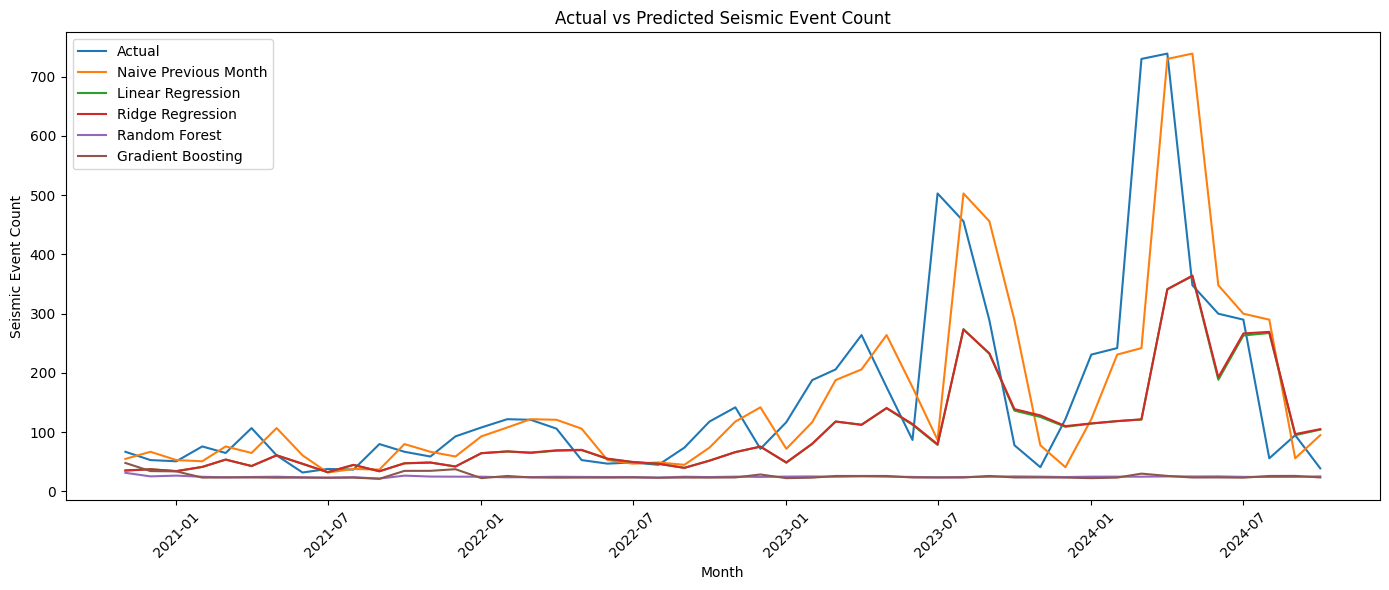

In [323]:
# ==========================================
# PART 22: ACTUAL VS PREDICTED VALUES
# ==========================================

plt.figure(figsize=(14, 6))

plt.plot(
    test_data['Month'],
    y_test_final,
    label='Actual'
)

plt.plot(
    test_data['Month'],
    final_naive_predictions,
    label='Naive Previous Month'
)

plt.plot(
    test_data['Month'],
    final_linear_predictions,
    label='Linear Regression'
)

plt.plot(
    test_data['Month'],
    final_ridge_predictions,
    label='Ridge Regression'
)

plt.plot(
    test_data['Month'],
    final_rf_predictions,
    label='Random Forest'
)

plt.plot(
    test_data['Month'],
    final_gb_predictions,
    label='Gradient Boosting'
)

plt.title('Actual vs Predicted Seismic Event Count')

plt.xlabel('Month')
plt.ylabel('Seismic Event Count')

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Part 23: Calculate Prediction Errors**

In [324]:
# ==========================================
# PART 23: RESIDUAL / ERROR ANALYSIS
# ==========================================

residual_data = pd.DataFrame({
    'Month': test_data['Month'].values,
    'Actual': y_test_final,
    'Predicted': final_naive_predictions
})

residual_data['Error'] = (
    residual_data['Actual']
    - residual_data['Predicted']
)

residual_data['Absolute_Error'] = (
    residual_data['Error'].abs()
)

display(residual_data.head(10))

,Month,Actual,Predicted,Error,Absolute_Error
188,2020-11-01,67.0,55.0,12.0,12.0
189,2020-12-01,53.0,67.0,-14.0,14.0
190,2021-01-01,51.0,53.0,-2.0,2.0
191,2021-02-01,76.0,51.0,25.0,25.0
192,2021-03-01,65.0,76.0,-11.0,11.0
193,2021-04-01,107.0,65.0,42.0,42.0
194,2021-05-01,61.0,107.0,-46.0,46.0
195,2021-06-01,32.0,61.0,-29.0,29.0
196,2021-07-01,38.0,32.0,6.0,6.0
197,2021-08-01,37.0,38.0,-1.0,1.0


In [325]:
print("Largest Prediction Errors")

largest_errors = residual_data.sort_values(
    'Absolute_Error',
    ascending=False
).head(10)

display(largest_errors)

Largest Prediction Errors


,Month,Actual,Predicted,Error,Absolute_Error
228,2024-03-01,730.0,242.0,488.0,488.0
220,2023-07-01,503.0,87.0,416.0,416.0
230,2024-05-01,348.0,739.0,-391.0,391.0
233,2024-08-01,56.0,290.0,-234.0,234.0
223,2023-10-01,78.0,289.0,-211.0,211.0
222,2023-09-01,289.0,456.0,-167.0,167.0
226,2024-01-01,231.0,122.0,109.0,109.0
219,2023-06-01,87.0,176.0,-89.0,89.0
218,2023-05-01,176.0,264.0,-88.0,88.0
225,2023-12-01,122.0,41.0,81.0,81.0


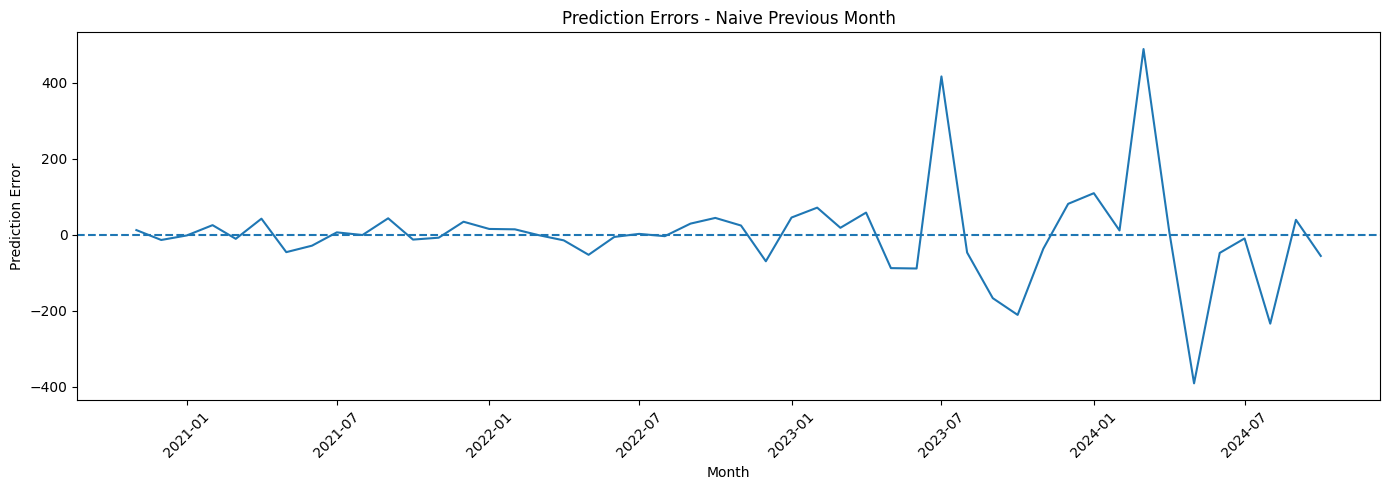

In [326]:
plt.figure(figsize=(14, 5))

plt.plot(
    residual_data['Month'],
    residual_data['Error']
)

plt.axhline(
    0,
    linestyle='--'
)

plt.title('Prediction Errors - Naive Previous Month')

plt.xlabel('Month')
plt.ylabel('Prediction Error')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Part 26: Final Model Selection**

We already have the evidence:

Time-Series Cross-Validation

In [327]:
# ==========================================
# PART 26: FINAL MODEL SELECTION
# ==========================================

final_summary = pd.DataFrame({
    'Metric': [
        'Cross-Validation MAE',
        'Cross-Validation RMSE',
        'Cross-Validation R2',
        'Final Test MAE',
        'Final Test RMSE',
        'Final Test R2'
    ],

    'Naive Previous Month': [
        correct_cv_results['MAE'].mean(),
        correct_cv_results['RMSE'].mean(),
        correct_cv_results['R2'].mean(),
        final_naive_mae,
        final_naive_rmse,
        final_naive_r2
    ]
})

display(
    final_summary.style.format({
        'Naive Previous Month': '{:.3f}'
    })
)

,Metric,Naive Previous Month
0,Cross-Validation MAE,5.568
1,Cross-Validation RMSE,8.760
2,Cross-Validation R2,-0.499
3,Final Test MAE,68.458
4,Final Test RMSE,126.475
5,Final Test R2,0.386


In [328]:
# ==========================================
# FINAL PREDICTION TABLE
# ==========================================

final_predictions_table = pd.DataFrame({
    'Month': test_data['Month'].values,
    'Actual': y_test_final,
    'Predicted': final_naive_predictions
})

final_predictions_table['Error'] = (
    final_predictions_table['Actual']
    - final_predictions_table['Predicted']
)

final_predictions_table['Absolute_Error'] = (
    final_predictions_table['Error'].abs()
)

display(final_predictions_table.head(15))

,Month,Actual,Predicted,Error,Absolute_Error
188,2020-11-01,67.0,55.0,12.0,12.0
189,2020-12-01,53.0,67.0,-14.0,14.0
190,2021-01-01,51.0,53.0,-2.0,2.0
191,2021-02-01,76.0,51.0,25.0,25.0
192,2021-03-01,65.0,76.0,-11.0,11.0
193,2021-04-01,107.0,65.0,42.0,42.0
194,2021-05-01,61.0,107.0,-46.0,46.0
195,2021-06-01,32.0,61.0,-29.0,29.0
196,2021-07-01,38.0,32.0,6.0,6.0
197,2021-08-01,37.0,38.0,-1.0,1.0


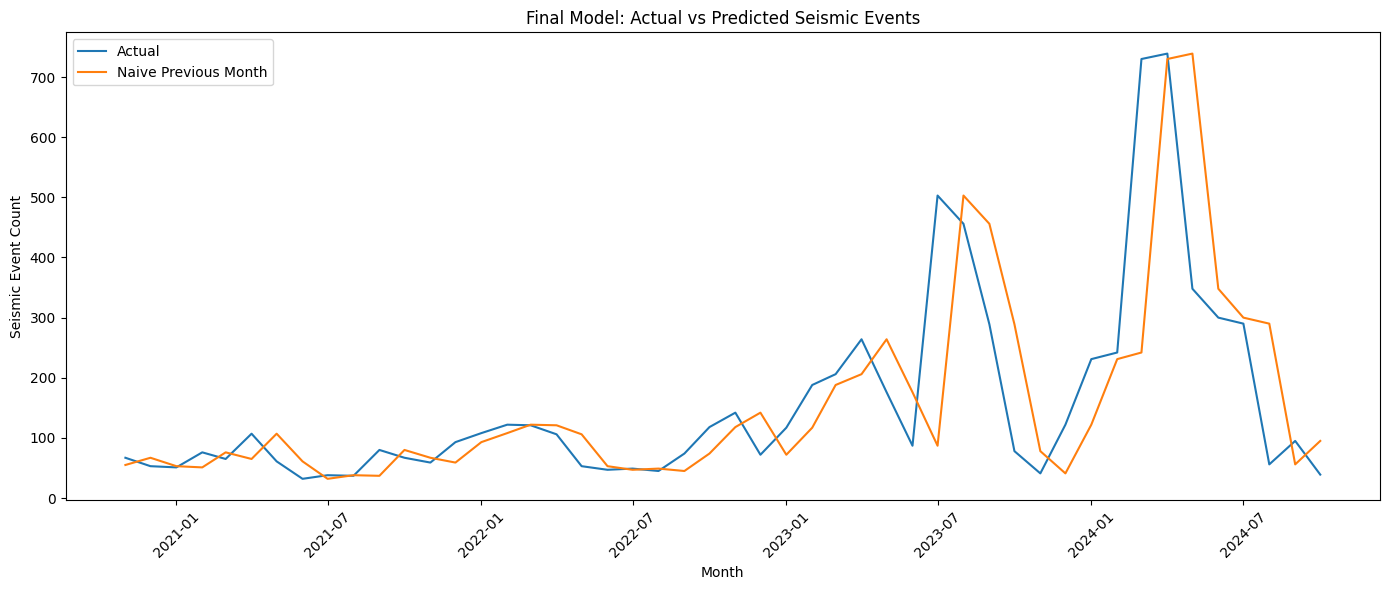

In [329]:
# ==========================================
# PART 27: FINAL MODEL VISUALIZATION
# ==========================================

plt.figure(figsize=(14, 6))

plt.plot(
    test_data['Month'],
    y_test_final,
    label='Actual'
)

plt.plot(
    test_data['Month'],
    final_naive_predictions,
    label='Naive Previous Month'
)

plt.title(
    'Final Model: Actual vs Predicted Seismic Events'
)

plt.xlabel('Month')
plt.ylabel('Seismic Event Count')

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

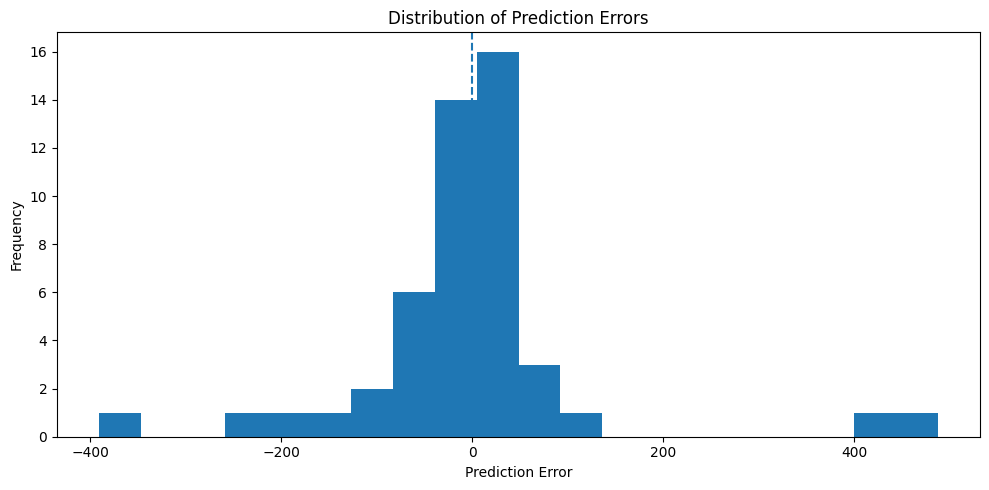

In [330]:
# ==========================================
# PART 28: ERROR DISTRIBUTION
# ==========================================

plt.figure(figsize=(10, 5))

plt.hist(
    residual_data['Error'],
    bins=20
)

plt.axvline(
    0,
    linestyle='--'
)

plt.title(
    'Distribution of Prediction Errors'
)

plt.xlabel('Prediction Error')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()